# Stage 2: Advanced Embedding Models Training and Analysis

## Libraries

In [1]:
!pip install gensim plotly scikit-learn
!pip install -q transformers peft bitsandbytes accelerate datasets evaluate
!pip install -q trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 14.9 MB/s eta 0:00:00


In [2]:
import os
import re
import multiprocessing
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, silhouette_score
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
import plotly.express as px
import plotly.io as pio
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from trl import SFTConfig
from trl import SFTTrainer
from datasets import Dataset
import evaluate
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
import time


## Environment setup

In your Google Drive, create a folder "CLT" and upload the csv ai_media_norm.csv.
In the folder CLT, create another folder "stage_2" and upload df_tm_topics.csv.

In Google Colab, GPU acceleration must be enabled before running chapter 4.
Navigate to **Runtime → Change runtime type** and select **L4 GPU** (or T4 GPU
on the free tier). Without a GPU, fine-tuning Qwen3-1.7B would take several hours instead of minutes.

All results chapter were produced on an **L4 GPU** (22.5 GB VRAM, available in Colab Pro). If you are running this on a **T4 GPU** (15 GB VRAM, free tier), processing times and memory availability will differ. In particular,
the batch size may need to be reduced to avoid out-of-memory errors.

> **HuggingFace Token required**: Downloading Qwen3 in Chapter 4 requires a free
> HuggingFace account and access token. Create one at
> [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens), then add
> it in Colab via the Secrets panel in the left sidebar as `HF_TOKEN`.


Switch: "local" (VS Code + GitHub) | "colab" (Google Colab + Drive)

In [3]:
ENV = "colab"
pio.renderers.default = "colab" if ENV == "colab" else "notebook"

In [4]:
if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


# 1 Dataset Preparation and Export

*Lead: Alla - Review: Marisa*

At this point, the Stage 1 preprocessing pipeline is complete [(Link to colab)](https://colab.research.google.com/github/allarom/clt-26/blob/main/clt.ipynb).
The dataset of Stage 1 is about 1.5 GB and we decided to
save only necessary data to `ai_media_norm.csv` containing the 10 columns needed for Stage 2, discarding all intermediate token and lemma variants that were used internally during cleaning.
This avoids repeating the computationally expensive and long spaCy processing (tokenization, lemmatization).

**Saved columns**
- `date`
- `domain`
- `url`
- `tags`
- `title`
- `content`
- `title_lemma_norm`
- `content_lemma_norm`
- `dominant_topic_idx`
- `topic_label`

This keeps the file small and focused — Stage 2 only needs the original metadata, the cleaned readable text, the final normalized lemma lists for embedding training, and the LDA topic labels for fine-tuning.




## 1.1 Load Stage 1 Checkpoint


We load the preprocessed dataset (`ai_media_norm.csv`).

Since CSV does not preserve Python list types, we use `ast.literal_eval` to restore `title_lemma_norm`, `content_lemma_norm`, and `tags` back to proper Python lists. The `date` column is also re-parsed to `datetime`.

In [5]:
if ENV == "colab":
    norm_path = '/content/drive/My Drive/CLT/ai_media_norm.csv'
else:
    norm_path = 'data/ai_media_norm.csv'

df_norm_loaded = pd.read_csv(norm_path, encoding='utf-8')

# Restore list columns serialized as strings by CSV
for col in ['title_lemma_norm', 'content_lemma_norm', 'tags']:
    df_norm_loaded[col] = df_norm_loaded[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

df_norm_loaded['date'] = pd.to_datetime(df_norm_loaded['date'])

print("Loaded shape:", df_norm_loaded.shape)

Loaded shape: (16518, 10)


## 1.2 Build Stage 2 Columns

For further analysis, we create the following columns:
- **`doc_id`**: Stable zero-padded identifier (e.g. `doc_00042`) — survives CSV export and links model outputs back to source articles.
- **`text_clean_light`**: Readable text from cleaned `title` + `content` — used for display, search, and labeling. Stop words kept, natural sentence structure preserved.
- **`text_for_embedding`**: Input for Word2Vec  — `title_lemma_norm` + `content_lemma_norm` joined as a space-separated string. Stop words removed, noise filtered.
- **`token_count`**: Number of tokens in `text_for_embedding`, used for quality filtering in the next step.





In [30]:
df_stage2 = df_norm_loaded.copy().reset_index(drop=True)

# Unique document ID
df_stage2['doc_id'] = ['doc_' + str(i).zfill(5) for i in range(len(df_stage2))]

# Readable combined text: cleaned title + cleaned content
df_stage2['text_clean_light'] = (
    df_stage2['title'].fillna('') + '. ' + df_stage2['content'].fillna('')
).str.strip('. ')

# Embedding text: final normalized lemma tokens from title + content joined
df_stage2['text_for_embedding'] = df_stage2.apply(
    lambda row: ' '.join(
        (row['title_lemma_norm'] if isinstance(row['title_lemma_norm'], list) else []) +
        (row['content_lemma_norm'] if isinstance(row['content_lemma_norm'], list) else [])
    ),
    axis=1
)

# Token count
df_stage2['token_count'] = df_stage2['text_for_embedding'].str.split().str.len()



## 1.3 Filter, Export and Verify

Before exporting we apply three quality filters to ensure only meaningful documents reach the embedding model:

1. **Remove empty embedding texts** — rows where `text_for_embedding` is blank or whitespace-only are dropped. These would produce zero-length inputs that crash or corrupt model training.
2. **Remove very short texts** — rows with fewer than 5 tokens are dropped. Documents this short carry almost no semantic signal and can distort word co-occurrence statistics in Word2Vec / FastText.
3. **Drop embedding duplicates** — rows whose `text_for_embedding` is identical to another row are deduplicated. Repeated documents would over-weight certain terms in the trained embeddings.

The index is then reset to close any gaps left by the filters, ensuring clean positional access. The final dataframe is narrowed to the 11 export columns and written to three CSV files(all UTF-8):
- `ai_media_stage2_full.csv`: The full dataset


A summary is printed showing the final shape, train/val counts, and a sample of the key columns.


In [31]:
# Remove empty / very short embedding texts
df_stage2 = df_stage2[df_stage2['text_for_embedding'].str.strip() != '']
df_stage2 = df_stage2[df_stage2['token_count'] >= 5]

# Drop duplicates based on embedding text
df_stage2 = df_stage2.drop_duplicates(subset='text_for_embedding').reset_index(drop=True)

if ENV == "colab":
    base_path = '/content/drive/My Drive/CLT/stage_2/'
else:
    base_path = 'data/stage_2/'

os.makedirs(base_path, exist_ok=True)


sample = df_stage2[['doc_id', 'text_clean_light', 'text_for_embedding', 'token_count']].head(3).copy()
print(sample.to_string())

      doc_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## 1.4 Dataset Preparation for Fine-Tuning

*Lead: Marisa - Review:* Alla

In Chapter 4 we fine-tune a language model to classify articles into AI topics.
To do this, every article needs a numeric label. We prepare that here close to the other data preparation steps so that the fine-tuning chapter can focus entirely on the model itself.

**Filters applied**

- **Filter 1 — Drop "Noise"**: This LDA topic groups documents that did not fit any meaningful category. It carries no useful signal for classification.

- **Filter 2 — Drop small classes**: Classes with fewer than 50 articles cannot be reliably split into train/val/test sets. With only a handful of examples per class, the model cannot learn meaningful patterns. This reduces our topics from 9 to 5 well-populated classes.

- **Filter 3 — Subsample to 5'000 articles**: The full dataset would take over 8 hours to train. A stratified sample of 5'000 articles preserves the class proportions of the full dataset while reducing training time to ~1 hour on a Colab Pro GPU.

**Label encoding**

The model works with integers, not text. We map each topic name to a number using the original Stage 1 index order, then re-map to contiguous 0-based integers after the filtering steps (e.g. if label 4 was dropped, labels 5-9 shift down accordingly).

**Train / validation / test split**

We apply a stratified 80 / 10 / 10 split:
- **Train (4'000 articles)**: used to update the model weights
- **Validation (500 articles)**: monitored during training to detect overfitting and select the best checkpoint
- **Test (500 articles)**: used only once at the very end to report the final results. It was never seen by the model during training.

In [32]:
df_clf = df_stage2[['doc_id', 'text_clean_light', 'text_for_embedding', 'topic_label']].copy()

print(f"df_stage2  : {len(df_stage2):,} rows")
print(f"df_clf     : {len(df_clf):,} rows")

# Filter 1: Drop Noise
df_clf = df_clf[df_clf['topic_label'] != 'Noise'].dropna(subset=['topic_label'])

# Filter 2: Drop classes with fewer than 50 articles
MIN_SAMPLES  = 50
valid_topics = df_clf['topic_label'].value_counts()
valid_topics = valid_topics[valid_topics >= MIN_SAMPLES].index.tolist()
df_clf       = df_clf[df_clf['topic_label'].isin(valid_topics)].copy()

print("\nRetained topics:")
print(df_clf['topic_label'].value_counts())

# Map topic names to integers
TOPIC_LABELS = [
    'AI and Business',
    'Financial Operations/Compliance',
    'Stock Market',
    'Geopolitics',
    'Noise',
    'Specific Institutions',
    'Medical Imaging',
    'Consumer Technology',
    'Digital Marketing',
    'Investments',
]
df_clf['label'] = df_clf['topic_label'].map(
    {label: idx for idx, label in enumerate(TOPIC_LABELS)}
).astype(int)

remaining        = sorted(df_clf['label'].unique())
remap            = {old: new for new, old in enumerate(remaining)}
df_clf['label']  = df_clf['label'].map(remap)
ID2LABEL_FINAL   = {new: TOPIC_LABELS[old] for old, new in remap.items()}
LABEL2ID_FINAL   = {v: k for k, v in ID2LABEL_FINAL.items()}
NUM_LABELS_FINAL = len(ID2LABEL_FINAL)

print(f"\nFinal classes ({NUM_LABELS_FINAL}):")
for idx, label in ID2LABEL_FINAL.items():
    print(f"  {idx} → {label}")

# Filter 3: Subsample to 5'000 articles
df_clf_sample, _ = train_test_split(
    df_clf, train_size=5000, random_state=42, stratify=df_clf['label']
)

# Stratified 80 / 10 / 10 split
df_train_clf, df_temp = train_test_split(
    df_clf_sample, test_size=0.20, random_state=42, stratify=df_clf_sample['label']
)
df_val_clf, df_test_clf = train_test_split(
    df_temp, test_size=0.50, random_state=42, stratify=df_temp['label']
)
print(f"\nSplit → train: {len(df_train_clf)} | val: {len(df_val_clf)} | test: {len(df_test_clf)}")

# Convert to HuggingFace Dataset objects
hf_train = Dataset.from_pandas(df_train_clf[['text_clean_light', 'label']].reset_index(drop=True))
hf_val   = Dataset.from_pandas(df_val_clf[['text_clean_light', 'label']].reset_index(drop=True))
hf_test  = Dataset.from_pandas(df_test_clf[['text_clean_light', 'label']].reset_index(drop=True))

print("hf_train / hf_val / hf_test ready.")

df_stage2  : 16,518 rows
df_clf     : 16,518 rows

Retained topics:
topic_label
AI and Business                    11374
Geopolitics                         4070
Investments                          568
Stock Market                         290
Financial Operations/Compliance       82
Name: count, dtype: int64

Final classes (5):
  0 → AI and Business
  1 → Financial Operations/Compliance
  2 → Stock Market
  3 → Geopolitics
  4 → Investments

Split → train: 4000 | val: 500 | test: 500
hf_train / hf_val / hf_test ready.


# 2 Word2Vec Embeddings

*Lead: Alla - Review: Marisa*

## 2.1 Load & Tokenize


During clustering, we observed that some cryptic tokens appeared frequently, which could distort the results. Many of these originated from Unicode artifacts or fragments of URLs left after preprocessing.

Additionally, spaCy’s lemmatization sometimes produced forms that are less meaningful in this context, such as datum (from data) or medium (from media), as already noted in Stage 1. These issues highlight the importance of inspecting and filtering tokens when preparing data for embedding and clustering.

A small normalization pass is applied before training to remap known lemmatization artifacts:

| Original token | Replacement | Reason |
|---|---|---|
| `datum` | `data` | spaCy lemmatises "data" → "datum" |
| `medium` | `media` | spaCy lemmatises "media" → "medium" |
| `u200b` | *(dropped)* | Unicode zero-width space (U+200B) leaked as literal token |
| `https`, `http` | *(dropped)* | URL protocol fragments from incompletely stripped hyperlinks |
| hex tokens | *(dropped)* | UTF-8 mojibake artifacts (`x9d`, `x80`, `x9cthe`, etc.) |

Counts before and after are printed so any additional odd tokens can be caught and added to `TOKEN_MAP`.

In [33]:

# Split space-separated token strings into lists — required format for gensim
sentences = [text.split() for text in df_train_clf['text_for_embedding'].dropna()]

# --- Token normalization ---
# TOKEN_MAP: explicit remappings (old → new, empty string = drop).
# HEX_PATTERN: drops any token starting with a hex escape sequence (x9d, x9cthe, etc.)
TOKEN_MAP = {
    'datum' : 'data',    # spaCy lemmatises "data" → "datum"
    'medium': 'media',   # spaCy lemmatises "media" → "medium"
    'u200b' : '',        # Unicode zero-width space leaked as literal token — drop
    'https' : '',        # URL protocol fragment — drop
    'http'  : '',        # URL protocol fragment — drop
}
HEX_PATTERN = re.compile(r'^x[0-9a-f]{2}')   # matches x9d, x80, x9cthe, etc.

def _keep(tok: str) -> str:
    """Return the normalised token, or '' to signal drop."""
    tok = TOKEN_MAP.get(tok, tok)          # apply explicit remapping first
    if HEX_PATTERN.match(tok):             # then drop hex artifacts
        return ''
    return tok

# Check counts before fix
from collections import Counter
flat_before   = [t for s in sentences for t in s]
flat_before   = [t for s in sentences for t in s]
counts_before = Counter(flat_before)
hex_before    = {t: c for t, c in counts_before.items() if HEX_PATTERN.match(t)}
print("=== Token counts BEFORE normalization ===")
for tok in TOKEN_MAP:
    print(f"  {tok:<12} : {counts_before.get(tok, 0):,}")
print(f"  hex artifacts: {sum(hex_before.values()):,} occurrences across {len(hex_before):,} unique tokens")

# Apply normalization
sentences = [
    [out for t in s for out in [_keep(t)] if out]
    for s in sentences
]

# Check counts after fix
flat_after   = [t for s in sentences for t in s]
counts_after = Counter(flat_after)
hex_after    = {t: c for t, c in counts_after.items() if HEX_PATTERN.match(t)}
print("\n=== Token counts AFTER normalization ===")
for orig, repl in TOKEN_MAP.items():
    print(f"  {orig:<12} → {repl:<12} : {counts_after.get(repl, 0):,}")
print(f"  hex artifacts remaining: {sum(hex_after.values()):,}")

print(f"\nDocuments  : {len(sentences):,}")
print(f"Total tokens: {sum(len(s) for s in sentences):,}")
print(f"Sample     : {sentences[0][:12]} ...")

=== Token counts BEFORE normalization ===
  datum        : 23,861
  medium       : 3,074
  u200b        : 222
  https        : 835
  http         : 122
  hex artifacts: 12,864 occurrences across 1,037 unique tokens

=== Token counts AFTER normalization ===
  datum        → data         : 29,051
  medium       → media        : 3,302
  u200b        →              : 0
  https        →              : 0
  http         →              : 0
  hex artifacts remaining: 0

Documents  : 4,000
Total tokens: 3,427,384
Sample     : ['download', 'xnview', 'mp', 'free', 'window', 'macos', 'linux', 'organise', 'view', 'manage', 'photo', 'effortlessly'] ...


Here we verify and count again, which tokens appear frequently.

In [34]:
flat_tokens = Counter(t for s in sentences for t in s)
TOP_FREQ    = 50   # show this many of the most frequent suspicious tokens per category

suspicious = {
    'hex_artifacts'  : {},   # x80, xc2, etc.
    'non_ascii'      : {},   # contains chars outside basic ASCII
    'numeric_only'   : {},   # pure numbers like "2023", "100"
    'single_char'    : {},   # single character tokens
    'punctuation'    : {},   # contains non-alphanumeric characters
}

for tok, cnt in flat_tokens.items():
    if re.fullmatch(r'x[0-9a-f]{2}', tok):
        suspicious['hex_artifacts'][tok] = cnt
    elif not tok.isascii():
        suspicious['non_ascii'][tok] = cnt
    elif tok.isnumeric():
        suspicious['numeric_only'][tok] = cnt
    elif len(tok) == 1:
        suspicious['single_char'][tok] = cnt
    elif not tok.isalpha():
        suspicious['punctuation'][tok] = cnt

for category, tokens in suspicious.items():
    top = sorted(tokens.items(), key=lambda x: x[1], reverse=True)[:TOP_FREQ]
    if top:
        print(f"\n{'='*50}")
        print(f"  {category.upper()}  ({len(tokens):,} unique tokens)")
        print(f"{'='*50}")
        for tok, cnt in top:
            print(f"  {tok:<20} : {cnt:,}")
    else:
        print(f"\n  {category}: ✓ none found")



  hex_artifacts: ✓ none found

  non_ascii: ✓ none found

  numeric_only: ✓ none found

  single_char: ✓ none found

  PUNCTUATION  (3,469 unique tokens)
  3d                   : 533
  r1                   : 342
  a16z                 : 265
  b2b                  : 230
  q1                   : 206
  4o                   : 197
  q4                   : 180
  yolov10              : 179
  15th                 : 170
  o1                   : 166
  4th                  : 154
  3rd                  : 138
  co2                  : 123
  20th                 : 120
  g7                   : 120
  j916                 : 119
  u200bmedium          : 119
  4k                   : 106
  1st                  : 106
  sc24                 : 105
  21st                 : 103
  net0                 : 103
  q2                   : 102
  1b                   : 100
  o3                   : 89
  jadc2                : 86
  a2a                  : 83
  v3                   : 79
  q3                   : 72
  8b     

## 2.1.1 Suspicious Token Scan

**Expected tokens in the `punctuation` category** — alphanumeric tokens containing digits are not artifacts; they are legitimate corpus vocabulary:

| Token(s) | Type | Examples |
|---|---|---|
| `3d`, `2d`, `4k` | Dimensional / display spec | 3D rendering, 4K video |
| `b2b`, `b2c` | Business model abbreviation | business-to-business, business-to-consumer |
| `r1`, `o1`, `o3`, `4o` | AI model names | DeepSeek R1, OpenAI o1/o3, GPT-4o |
| `q1` – `q4` | Fiscal quarters | Q1 earnings, Q4 results |
| `8b`, `70b`, `1b`, `3b` | Model parameter scale | 8-billion-parameter model |
| `v1`, `v2`, `v3` | Version numbers | model version, API version |
| `h100`, `gb200` | GPU / hardware names | NVIDIA H100, GB200 |
| `10x`, `5x` | Growth multipliers | 10× revenue growth |
| `a16z` | VC fund shorthand | Andreessen Horowitz |
| `web3`, `co2`, `g7` | Domain terms | Web3 ecosystem, CO₂ emissions, G7 summit |
| ordinals (`1st`…`30th`) | Date ordinals | published on the 15th |

These should all be **kept** — they carry real semantic signal for the AI-media domain.


## 2.2 Train Word2Vec



We train a **Skip-gram Word2Vec** model on the `text_for_embedding` column of the training split.
The input tokens are the pre-processed lemma sequences produced in Stage 1 (stop words removed, normalised).

**Role in the broader pipeline:**  
Word2Vec operates on individual lemma tokens, not BPE (Byte Pair Encoding) subwords.

They serve as:
- a **domain vocabulary sanity check** — nearest-neighbour probes reveal whether the corpus signal is coherent;
- **embedding initialisation** for lightweight classification or retrieval heads built on top of the LLM;
- **input features** for non-neural baselines (TF-IDF + W2V centroid classifiers, etc.).

**Hyperparameters chosen:**

| Parameter | Value | Rationale |
|---|---|---|
| `vector_size` | 200 | Good balance for ~16 k documents |
| `window` | 5 | Standard context window |
| `min_count` | 5 | Drop tokens appearing fewer than 5 times |
| `sg` | 1 | Skip-gram; better for rare domain terms |
| `epochs` | 10 | Sufficient for convergence on this corpus size |


Training uses all available CPU cores.

In [11]:
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,   # embedding dimensions
    window=5,          # context window
    min_count=5,       # ignore tokens appearing fewer than 5 times
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    workers=multiprocessing.cpu_count(),
    epochs=10,
    seed=42,
)

print(f"Vocabulary size : {len(w2v_model.wv):,} tokens")
print(f"Vector dimensions: {w2v_model.wv.vector_size}")


Vocabulary size : 21,708 tokens
Vector dimensions: 200


## 2.3 Save Model



Two artefacts are saved to `data/stage_2/embeddings/`:

- **`w2v_ai_media.model`** — full [Gensim](https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.html) model (can be reloaded for further training or inference).
- **`w2v_ai_media_vectors.txt`** — plain-text word vectors in `word2vec` format, compatible with external tools (FastText, Magnitude, `load_facebook_vectors`, etc.).

In [35]:
if ENV == "colab":
    model_dir = '/content/drive/My Drive/CLT/stage_2/embeddings/'
else:
    model_dir = 'data/stage_2/embeddings/'

os.makedirs(model_dir, exist_ok=True)

# Full gensim model (reloadable)
w2v_model.save(model_dir + 'w2v_ai_media.model')

# Plain-text vectors (word2vec format — compatible with external tools)
w2v_model.wv.save_word2vec_format(model_dir + 'w2v_ai_media_vectors.txt', binary=False)

print("Saved to:", model_dir)


Saved to: /content/drive/My Drive/CLT/stage_2/embeddings/


## 2.4 Evaluate



Nearest-neighbour probes confirm the model has learned domain-coherent representations.
We test a small set of AI-media terms `probe_words`.
We also print the top-20 tokens by frequency to quickly spot any noise that survived the earlier cleaning steps.

In [36]:
wv = w2v_model.wv

# --- Nearest-neighbour probes ---
probe_words = ['ai', 'model', 'work', 'bias', 'security']

print("=== Nearest-neighbour probes (top 5) ===")
for word in probe_words:
    if word in wv:
        neighbours = wv.most_similar(word, topn=5)
        neighbours_str = ', '.join(f"{w} ({s:.2f})" for w, s in neighbours)
        print(f"  {word:<12} → {neighbours_str}")
    else:
        print(f"  {word:<12} → not in vocabulary")

# --- Top-20 tokens by frequency ---
print("\n=== Top-20 tokens by frequency ===")
vocab_counts = sorted(wv.key_to_index.keys(),
                      key=lambda w: w2v_model.wv.get_vecattr(w, 'count'),
                      reverse=True)[:20]
for i, w in enumerate(vocab_counts, 1):
    count = w2v_model.wv.get_vecattr(w, 'count')
    print(f"  {i:>2}. {w:<20} {count:,}")


=== Nearest-neighbour probes (top 5) ===
  ai           → genai (0.64), generative (0.62), digitate (0.59), businessolver (0.59), harnessing (0.58)
  model        → grm (0.68), lamda (0.68), sfr (0.68), hunyuan (0.68), olmo (0.67)
  work         → starner (0.56), chalson (0.54), busywork (0.53), reskill (0.52), reconnecte (0.52)
  bias         → prejudice (0.65), perpetuate (0.63), fairness (0.63), biased (0.61), underfitte (0.58)
  security     → cybersecurity (0.59), sentra (0.56), watchtowr (0.54), commvault (0.53), vulnerability (0.51)

=== Top-20 tokens by frequency ===
   1. ai                   50,641
   2. data                 29,051
   3. use                  23,660
   4. model                21,807
   5. company              19,819
   6. new                  14,406
   7. time                 14,073
   8. like                 13,559
   9. technology           13,313
  10. system               13,136
  11. year                 12,130
  12. business             11,608
  13. work

---

Nearest-neighbour probes confirm the model has learned domain-coherent representations. We test a small set of AI-media terms and print the top-20 tokens by frequency to quickly spot any noise that survived the earlier cleaning steps.

**Embedding evaluation**

The nearest-neighbour analysis confirms that the embeddings capture meaningful semantic relationships in the dataset:

- **`ai`** clusters with `genai` and `generative`, reflecting the dominant discourse around generative AI systems in the corpus.
- **`bias`** is closely associated with `fairness`, `prejudice`, and `perpetuate`, reflecting discussions around AI ethics — a coherent and expected cluster.
- **`security`** links to `cybersecurity`, `sentra`, and `vulnerability`, confirming a coherent cybersecurity sub-cluster.
- **`model`** connects to highly specific technical systems (`lamda`, `grm`, `paligemma`), suggesting awareness of modern model architectures.
- **`work`** the terms `busywork`, `shewmaker`  exhibit moderate semantic similarity to the target concept.

**Dataset structure**

The top-20 most frequent tokens confirm the corpus focus: `ai`, `data`, `model`, `use`, and `company` dominate the vocabulary, reflecting the dataset's primary themes of AI technology and business adoption. The absence of noise tokens in the top-20 confirms that the normalization pass in Section 2.1 was effective.


# 3 Cluster Visualisation

*Lead: Alla - Review: Marisa*

We project the Word2Vec **vocabulary** into 2D using **t-SNE**, then assign each word to a thematic cluster using **K-Means**.
Each point in the interactive plot is one vocabulary token. Points that are close together share similar contexts in the corpus — hovering reveals the word and its frequency.

**Pipeline:**
1. Take the top `TOP_N` most-frequent words (keeps the plot readable and focuses on signal-rich terms).
2. L2-normalise the vectors (equivalent to cosine similarity for K-Means).
3. Reduce to 2D with t-SNE (`perplexity=40`, `n_iter=1000`).
4. Cluster with K-Means (`N_CLUSTERS` groups).
5. Render as an interactive Plotly scatter — point size scales with token frequency.


## 3.1 Configure & Extract Vectors



Adjust `TOP_N` and `N_CLUSTERS` to trade off detail vs. readability.
A good starting point is 2 000–4 000 words and 6–12 clusters for an AI-media corpus of this size.

In [37]:
TOP_N      = 3000   # most-frequent words to include in the plot
N_CLUSTERS = 12     # number of thematic clusters

# Sort vocabulary by frequency descending, take top N
words_sorted = sorted(
    wv.key_to_index.keys(),
    key=lambda w: wv.get_vecattr(w, 'count'),
    reverse=True
)[:TOP_N]

vectors = np.array([wv[w] for w in words_sorted])
freqs   = np.array([wv.get_vecattr(w, 'count') for w in words_sorted])



print(f"Words selected : {len(words_sorted):,}")
print(f"Vector matrix  : {vectors.shape}")
print(f"Frequency range: {freqs.min():,} – {freqs.max():,}")

Words selected : 3,000
Vector matrix  : (3000, 200)
Frequency range: 152 – 50,641


## 3.2 Optimal K — Elbow & Silhouette

Before fixing `N_CLUSTERS` we sweep K = 2 … 12 on the L2-normalised vectors and plot two diagnostics:

- **Elbow (inertia)** — within-cluster sum of squares; look for the point where the curve bends and further gains shrink.
- **Silhouette score** — mean similarity of each word to its own cluster vs. the next-best cluster; ranges 0–1, higher is better; pick the peak.

Both charts use the same high-dimensional normalised vectors (not the 2D t-SNE projection) so the K choice is grounded in the actual embedding geometry.


In [38]:
K_RANGE = range(2, 13)

vectors_norm_k = normalize(vectors)   # L2-normalise for cosine-like K-Means

inertias    = []
silhouettes = []

for k in K_RANGE:
    km_k = KMeans(n_clusters=k, random_state=42, n_init='auto')
    lbl  = km_k.fit_predict(vectors_norm_k)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(vectors_norm_k, lbl, sample_size=1500, random_state=42))
    print(f"  k={k:2d}  inertia={km_k.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

# --- Plot both diagnostics side-by-side ---
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig_k = make_subplots(rows=1, cols=2,
                      subplot_titles=('Elbow — Inertia (lower is better)',
                                      'Silhouette Score (higher is better)'))

fig_k.add_trace(go.Scatter(x=list(K_RANGE), y=inertias,
                            mode='lines+markers', name='Inertia',
                            line=dict(color='steelblue', width=2),
                            marker=dict(size=7)), row=1, col=1)

fig_k.add_trace(go.Scatter(x=list(K_RANGE), y=silhouettes,
                            mode='lines+markers', name='Silhouette',
                            line=dict(color='tomato', width=2),
                            marker=dict(size=7)), row=1, col=2)

# Mark the chosen N_CLUSTERS on both subplots
for col in [1, 2]:
    fig_k.add_vline(x=N_CLUSTERS, line_dash='dash', line_color='grey',
                    annotation_text=f'N_CLUSTERS={N_CLUSTERS}',
                    annotation_position='top right', row=1, col=col)

fig_k.update_xaxes(title_text='K', dtick=1)
fig_k.update_layout(title_text='Optimal K selection for K-Means clustering',
                    width=1000, height=420, showlegend=False)
fig_k.show()


  k= 2  inertia=2,514  silhouette=0.0166
  k= 3  inertia=2,488  silhouette=0.0126
  k= 4  inertia=2,465  silhouette=0.0133
  k= 5  inertia=2,446  silhouette=0.0135
  k= 6  inertia=2,430  silhouette=0.0139
  k= 7  inertia=2,414  silhouette=0.0143
  k= 8  inertia=2,404  silhouette=0.0146
  k= 9  inertia=2,395  silhouette=0.0141
  k=10  inertia=2,381  silhouette=0.0148
  k=11  inertia=2,369  silhouette=0.0158
  k=12  inertia=2,356  silhouette=0.0166


**K-Means Cluster Evaluation**

To determine the appropriate number of clusters, we evaluated K-Means performance for K = 2–12 using both inertia (elbow method) and silhouette score.

The inertia values decrease steadily as K increases (from 2514 at K=2 to 2355 at K=12), which is expected since adding more clusters reduces within-cluster variance. However, the decrease is gradual and does not show a clear elbow point, suggesting that the dataset does not have strongly separated cluster boundaries.

The silhouette scores are relatively low across all K values (≈0.012–0.016), indicating that the clusters are only weakly separated in the embedding space. This is common in high-dimensional semantic embeddings where topics overlap. The highest silhouette score occurs at K=12 (0.0166).

Based on these diagnostics, 12 clusters were selected. Although the improvement is modest, this value provides slightly better cluster separation while allowing for more granular thematic grouping of AI-related topics in the dataset.

**Reproducibility Note:**
Although a fixed random_state is used for K-Means and silhouette sampling, the results may still vary slightly across runs. This is due to factors such as the stochastic nature of K-Means initialization, the use of approximate sampling in silhouette scoring, and potential non-determinism in underlying numerical libraries. Consequently, inertia and silhouette values—and the selected optimal number of clusters—should be interpreted as approximate indicators rather than exact, fully reproducible metrics.

## 3.3 t-SNE Reduction & K-Means Clustering

Vectors are L2-normalised before t-SNE so distances approximate cosine similarity.
t-SNE takes ~30–60 s on 3 000 points with `n_jobs=1` (single-threaded to avoid Cython issues).

K-Means is applied **on the 2D t-SNE coordinates** (not the original 200-dim vectors).
This ensures every cluster forms a spatially contiguous region in the plot — no colour will appear in two separate corners.


In [39]:
# L2-normalise (cosine similarity)
vectors_norm = normalize(vectors)

# t-SNE: reduce 200-dim → 2-dim
print("Running t-SNE …")
tsne   = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=1)
coords = tsne.fit_transform(vectors_norm)

# K-Means on 2D t-SNE coords — clusters will be spatially coherent in the plot
km     = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
labels = km.fit_predict(coords)

print("Done.\nCluster sizes:")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    mask      = labels == u
    top_words = [words_sorted[i] for i in np.where(mask)[0][:15]]
    print(f"  Cluster {u} ({c:>4} words) — sample: {', '.join(top_words)}")


Running t-SNE …
Done.
Cluster sizes:
  Cluster 0 ( 185 words) — sample: new, policy, center, partner, state, health, group, late, patient, public, view, healthcare, startup, launch, announce
  Cluster 1 ( 290 words) — sample: data, model, large, language, information, machine, learn, result, learning, generate, open, source, search, level, training
  Cluster 2 ( 248 words) — sample: time, customer, service, high, industry, product, cost, risk, software, increase, content, million, growth, grow, billion
  Cluster 3 ( 261 words) — sample: like, need, include, base, create, human, example, challenge, case, set, different, require, problem, understand, specific
  Cluster 4 ( 224 words) — sample: security, energy, space, area, robot, supply, chain, chip, threat, robotic, protect, production, vehicle, autonomous, personal
  Cluster 5 ( 252 words) — sample: good, way, come, know, look, think, want, find, long, term, start, question, end, today, thing
  Cluster 6 ( 258 words) — sample: digital

**Cluster Interpretation**

The clustering reveals 12 thematic dimensions of AI discourse in the dataset. These clusters can be grouped into several broader categories.

For each cluster, we examined the most frequent or characteristic tokens and identified the common semantic theme connecting them. We looked at contextual words and considered domain knowledge. Based on this interpretation, concise labels were created to reflect the dominant topic or discourse dimension represented by the cluster.

Attention, cluster numbers are random assigned and content may vary, because TSNE is non-deterministic, in the next chapter we will explain how we deal with it in the visualization.


##1. Technical AI & Systems

`AI Models & Data: data, model, language, learning`

`Digital Infrastructure & Computing: cloud, network, computing, device`

`Systems, Tools & Support: system, platform, tool, user`

These clusters represent the technical foundations of AI, including models, data processing, digital infrastructure, and system-level tools enabling deployment and interaction.

##2. Business, Products & Markets

`Business, Markets & Investment: company, market, stock`

`Products, Services & Growth: customer, product, service`

These clusters capture commercial activity, market dynamics, and the delivery and scaling of AI-driven products and services.

##3. Governance, Policy & Risk

`Global Policy & Geopolitics: global, government, china, policy`

`Security, Robotics & Infrastructure: security, threat, supply, autonomous`


They reflect discussions around regulation, geopolitical competition, and operational concerns such as security, infrastructure, and public-sector or partnership-driven initiatives.

##4. Industry & Applied Domains

`Policy, Health & Partnerships: health, patient, healthcare`

This cluster represents domain-specific applications of AI, particularly in healthcare and public-sector contexts.

##5. Research & Work Context

`Research, Leadership & Communication: research, study, team, leader`

This cluster reflects academic research, organizational structures, and communication practices surrounding AI.

##6. AI Innovation & Future

`AI Innovation & Strategy: ai, technology, future, development`

This cluster captures forward-looking discussions about technological progress, strategic development, and the broader impact of AI.

##7. Usage, Problem-Solving & Narrative Language

`Support, Usage & Enablement: use, help, support, provide`

`Problems & Human-Centred Reasoning: problem, challenge, example, human`

`General Reasoning & Conversation: people, think, know, want`

These clusters capture practical interaction with AI systems, including usage and problem-solving, as well as general reasoning and conversational language that frames and interprets these processes.

Overall, the clusters show that the dataset covers technical AI development, business adoption, governance, research, and societal implications, reflecting the multidimensional nature of AI discourse.

**Reproducibility Note:**
The results of this visualization are not fully deterministic. Although a fixed random_state is used, t-SNE is inherently stochastic and sensitive to initialization and parameter settings (e.g., perplexity). Small variations in the embedding can lead to different spatial arrangements and, consequently, different K-Means cluster assignments. Therefore, cluster positions, boundaries, and labels may vary slightly across runs and should be interpreted as approximate rather than fixed.


## 3.4 Interactive Plot

**Automatic Cluster Labelling via Anchor-Word Matching**

Since K-Means cluster IDs are arbitrary and may change between runs, clusters were labelled using a content-based anchor-word matching procedure rather than relying on cluster indices.

For each of the twelve predefined themes (e.g., AI Models & Data, Ethics & Safety), a small set of representative anchor words (9–12 terms) was manually defined based on domain knowledge of the AI media corpus.

For every cluster 𝑐 and theme 𝑡, a matching score was computed as the normalized overlap between the cluster vocabulary 𝑉𝑐 and the theme’s anchor set 𝐴𝑡:

$\text{score}(c,t) = \frac{|V_c \cap A_t|}{|A_t|}$

All cluster–theme pairs were ranked by this score and assigned using a greedy one-to-one procedure, ensuring that each cluster receives one label and each theme is used at most once. If no overlap was found, a fallback label was created from the cluster’s three most frequent words.

This procedure ensures fully automatic and reproducible cluster labelling, independent of K-Means initialization.

Each point is one vocabulary word.
**Size** scales with token frequency — larger dots are the most common terms in the corpus.
**Colour** represents the K-Means cluster.
Hover any point to see the word and its raw frequency count.


In [40]:
# Anchor words for each theme — the cluster whose vocabulary best matches
# a set of anchors gets that name automatically (robust to ID shuffling across runs).
THEME_ANCHORS = {
    'Policy, Health & Partnerships': ['policy', 'state', 'health', 'patient', 'healthcare', 'public', 'partner', 'startup', 'launch', 'announce', 'center'],
    'AI Models & Data': ['data', 'model', 'language', 'machine', 'learning', 'generate', 'training', 'search', 'open', 'source', 'information'],
    'Products, Services & Growth': ['customer', 'service', 'product', 'software', 'industry', 'cost', 'risk', 'growth', 'million', 'billion', 'content'],
    'Problems & Human-Centred Reasoning': ['human', 'problem', 'challenge', 'case', 'example', 'different', 'understand', 'specific', 'need', 'include', 'create'],
    'Security, Robotics & Infrastructure': ['security', 'robot', 'robotic', 'chip', 'threat', 'protect', 'supply', 'chain', 'vehicle', 'autonomous', 'energy'],
    'General Reasoning & Conversation': ['good', 'way', 'know', 'think', 'want', 'find', 'question', 'today', 'thing', 'look', 'term'],
    'Digital Infrastructure & Computing': ['digital', 'cloud', 'quantum', 'network', 'computer', 'computing', 'device', 'app', 'processing', 'edge', 'smart'],
    'Business, Markets & Investment': ['company', 'business', 'market', 'stock', 'value', 'investment', 'buy', 'report', 'share', 'organization', 'year'],
    'Systems, Tools & Support': ['system', 'tool', 'platform', 'solution', 'user', 'support', 'agent', 'design', 'process', 'provide', 'help'],
    'AI Innovation & Strategy': ['ai', 'technology', 'build', 'drive', 'development', 'intelligence', 'future', 'develop', 'strategy', 'project', 'change'],
    'Research, Leadership & Communication': ['research', 'study', 'science', 'team', 'lead', 'leader', 'people', 'email', 'update', 'article', 'privacy'],
    'Global Policy & Geopolitics': ['global', 'china', 'government', 'trump', 'country', 'united', 'states', 'international', 'trade', 'economic', 'national'],
}

# --- Build top-words lookup per cluster ---
cluster_top_words = {}
cluster_word_sets = {}
for cid in sorted(np.unique(labels)):
    idx_sorted = sorted(np.where(labels == cid)[0], key=lambda i: freqs[i], reverse=True)
    cluster_top_words[cid] = [words_sorted[i] for i in idx_sorted[:3]]
    cluster_word_sets[cid]  = set(words_sorted[i] for i in np.where(labels == cid)[0])

# --- Auto-assign theme names via anchor-word matching ---
# Each cluster gets the theme whose anchors overlap most with its vocabulary.
# Each theme is assigned at most once (greedy best-match).
assigned_themes = {}
used_themes     = set()
scores = {
    cid: {
        # Normalize by anchor count so small clusters aren't penalised vs. large ones
        theme: len(cluster_word_sets[cid] & set(anchors)) / len(anchors)
        for theme, anchors in THEME_ANCHORS.items()
    }
    for cid in sorted(np.unique(labels))
}
all_pairs = sorted(
    [(cid, theme) for cid in scores for theme in scores[cid]],
    key=lambda p: scores[p[0]][p[1]], reverse=True
)
for cid, theme in all_pairs:
    if cid not in assigned_themes and theme not in used_themes:
        assigned_themes[cid] = theme
        used_themes.add(theme)
for cid in sorted(np.unique(labels)):
    if cid not in assigned_themes:
        assigned_themes[cid] = ' / '.join(cluster_top_words[cid])

print("Auto-assigned cluster names:")
for cid, name in sorted(assigned_themes.items()):
    print(f"  Cluster {cid}: {name}  (top words: {', '.join(cluster_top_words[cid])})")

def _cluster_label(cid):
    return assigned_themes[cid]

# Centroid coordinates in t-SNE space
centroids = {
    cid: (coords[labels == cid, 0].mean(), coords[labels == cid, 1].mean())
    for cid in sorted(np.unique(labels))
}

df_viz = pd.DataFrame({
    'x'      : coords[:, 0],
    'y'      : coords[:, 1],
    'word'   : words_sorted,
    'cluster': [_cluster_label(l) for l in labels],
    'freq'   : freqs,
})

fig = px.scatter(
    df_viz,
    x='x', y='y',
    color='cluster',
    hover_name='word',
    hover_data={'freq': ':,', 'cluster': True, 'x': False, 'y': False},
    size='freq',
    size_max=25,
    opacity=0.70,
    title=f't-SNE of Word2Vec vocabulary — {N_CLUSTERS} K-Means clusters  (top {TOP_N:,} words)',
    width=1200,
    height=840,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_traces(marker=dict(line=dict(width=0)))

# Centroid label boxes — cluster name
for cid, (cx, cy) in centroids.items():
    fig.add_annotation(
        x=cx, y=cy,
        text=f'<b>{_cluster_label(cid)}</b>',
        showarrow=False,
        font=dict(size=12, color='#111'),
        bgcolor='rgba(255,255,255,0.82)',
        bordercolor='#999',
        borderwidth=1,
        borderpad=5,
    )

fig.update_layout(
    legend_title_text='Cluster',
    legend=dict(font=dict(size=11)),
    xaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
    yaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
)
fig.show()



Auto-assigned cluster names:
  Cluster 0: Policy, Health & Partnerships  (top words: new, policy, center)
  Cluster 1: AI Models & Data  (top words: data, model, large)
  Cluster 2: Products, Services & Growth  (top words: time, customer, service)
  Cluster 3: Problems & Human-Centred Reasoning  (top words: like, need, include)
  Cluster 4: Security, Robotics & Infrastructure  (top words: security, energy, space)
  Cluster 5: General Reasoning & Conversation  (top words: good, way, come)
  Cluster 6: Digital Infrastructure & Computing  (top words: digital, cloud, quantum)
  Cluster 7: Business, Markets & Investment  (top words: company, year, business)
  Cluster 8: Systems, Tools & Support  (top words: use, system, help)
  Cluster 9: AI Innovation & Strategy  (top words: ai, technology, work)
  Cluster 10: Research, Leadership & Communication  (top words: team, research, lead)
  Cluster 11: Global Policy & Geopolitics  (top words: world, global, china)


**Interpretation of the t-SNE Visualization**

The t-SNE projection illustrates the semantic organisation of the Word2Vec vocabulary, where words with similar contextual usage appear close to each other. The resulting clusters reflect several thematic areas within the AI discourse dataset.
It is important to note that this visualization represents a 2-dimensional projection of a high-dimensional embedding space, which has its own caveats and is just a model to give some insights of how data is clustered.
Also this visualisation is non-deterministic and may render differently each run.

**Spatial organisation**

*   `AI Models & Data and Digital Infrastructure & Computing` are positioned close to each other, indicating a strong semantic connection between core AI technologies and the underlying computational infrastructure that supports them.

*   `Systems, Tools & Support` lies nearby, reinforcing the link to practical implementation and usage.
*   `Products, Services & Growth and Business, Markets & Investment` are located near each other, highlighting the close relationship between AI technologies and their commercial applications, market dynamics, and financial scaling.
*   `Global Policy & Geopolitics` is positioned close to both `Business, Markets & Investment and Policy, Health & Partnerships`, indicating a strong connection between regulatory, geopolitical dynamics, and economic as well as public-sector activities.
*   `Security, Robotics & Infrastructure` forms a more distinct cluster, representing specialized domains such as autonomous systems, hardware, and security-related concerns within AI applications.
*   `AI Innovation & Strategy` is positioned near the center, linking technical development, business strategy, and broader future-oriented discussions.
`Research, Leadership & Communication` connects technical and organizational dimensions, reflecting academic research, leadership structures, and communication practices.
*   `Problems & Human-Centred Reasoning, and General Reasoning & Conversation` form a more diffuse region, capturing general-purpose, interactional, and explanatory language that underpins how AI is discussed and understood.

**Reproducibility Note:**
The automatic cluster labels may vary across runs because they depend on the cluster composition generated in earlier stochastic steps. As a result, theme assignments should be interpreted as approximate.


**Limitations of the 2D projection**

It is important to note that this visualization represents a 2-dimensional projection of a high-dimensional embedding space. Consequently:

- Distances between clusters may be distorted due to dimensionality reduction.

- t-SNE preserves local neighbourhood relationships better than global structure.

- Clusters that appear close in the plot may not be equally close in the original embedding space.

Therefore, the visualization should be interpreted as an approximate representation of semantic relationships, useful for identifying thematic patterns but not for precise distance comparisons.

# 4 Finetuning and Comparison

*Lead: Marisa - Review: Bianca*

Why Fine-Tune a Language Model?
In Chapter 2 we trained Word2Vec, a classical embedding model. Word2Vec learns a fixed vector for each word by looking at its neighbouring words in a small window of ±5 tokens. The word "model" always gets the same vector, regardless of whether the sentence is about "a business model" or "a language model".

Fine-tuned transformer-based language models work differently: instead of a fixed window, they process the entire document at once and can relate any word to any other word in the text. This means the representation of "model" changes depending on its context. This is called dynamic or contextualised representation.
Why finetune a model? Word2Vec (Chapter 2) learns static token-level representations: each word gets a fixed vector regardless of context.
Fine-tuned **transformer-based language models** go further:

| Property | Word2Vec | Fine-tuned LLM |
|---|---|---|
| Context | Local window (±5 tokens) | Full document (bi-directional attention) |
| Representation | Static: One fixed vector per word | Dynamic: Changes with context |
| For classification | Needs a separate classifier on top | Classification head trained end-to-end |
| Training cost | Minutes (CPU) | 5-60 min (GPU) |

On classification heads:
Word2Vec produces vectors, but has no notion of "topic" or "class". To use it for classification, you need to add a separate model on top — in our case a Logistic Regression (Section 4.9). These two components are trained independently: first Word2Vec on the raw text, then Logistic Regression on the resulting vectors.

A fine-tuned LLM works differently. We attach a small classification head — a single linear layer that maps the model's output to our 5 topic classes. Crucially, this head is trained together with the rest of the model in one single training run. The model therefore learns representations that are directly optimised for the classification task, rather than general-purpose word similarity.

## 4.1 Task: Multi-Class Topic Classification


We frame fine-tuning as a 9-class topic classification task. The original LDA model
produced 10 topics, but we drop the "Noise" class. This topic groups documents that
did not fit cleanly into any meaningful category and therefore carries no useful signal
for trend classification.

The remaining 9 topics are:

| Label | Topic | Typical content |
|---|---|---|
| 0 | AI and Business | Corporate AI adoption, enterprise strategy |
| 1 | Financial Operations/Compliance | RegTech, auditing, financial AI |
| 2 | Stock Market | Market movements, AI-driven trading |
| 3 | Geopolitics | US-China tensions, AI regulation, national strategy |
| 4 | Specific Institutions | Named companies, universities, labs |
| 5 | Medical Imaging | Healthcare AI, diagnostics |
| 6 | Consumer Technology | Devices, apps, user-facing AI |
| 7 | Digital Marketing | Ad tech, content generation, SEO |
| 8 | Investments | VC funding, startup ecosystems |

**Why we use LDA labels as training signal**

To train a classifier, every article needs a label. Manually annotating 16'000 articles would be impractical. Instead, we use the topic assignments that LDA produced in Stage 1. This is called silver labeling: labels that are automatically generated rather than hand-annotated by humans. Silver labeling is standard practice in NLP when manual annotation is infeasible.

LDA's labels are a good fit here because they were derived directly from the vocabulary of this corpus and not from a generic external source. They are also reproducible: running LDA with the same random_state always produces the same assignments.

>**Known limitation:** LDA assigns each document a probability distribution over all topics and then picks the most likely one (argmax). For articles that sit between two topics — e.g an article about AI investment regulation that could belong to either Geopolitics or Investments — the assigned label may not be the most natural one. This introduces some label noise in borderline cases.
>
>We account for this in two ways: we use macro F1 as our evaluation metric, and we
explicitly analyse where Qwen3 disagrees with LDA in Section 4.8.
>
>F1 is a metric that combines two properties: precision (of all articles the model
assigned to a topic, how many actually belong there?) and recall (of all articles that
belong to a topic, how many did the model find?). A high F1 requires both to be good.
The *macro* variant computes F1 separately for each topic and then averages them,
meaning a small topic like "Stock Market" counts just as much as the dominant
"AI and Business" class. This makes macro F1 more informative than plain accuracy,
which would be dominated by the majority class.

## 4.2 Model Choice

We use `Qwen3-1.7B`, a compact open-source language model by Alibaba. "1.7B" refers to 1.7 billion parameters which are the learned weights that define the model's behaviour. Despite its size, it runs on a single GPU with 4-bit quantisation.

Several candidate models were considered for this task, including TinyLlama (1.1B), Gemma 2B, Gemma 7B, DeepSeek-R1-Distill-Qwen-1.5B, and Qwen3-4B. We selected Qwen3-1.7B for the following reasons:

- **Fits on Colab**: with QLoRA quantisation it uses ~2 GB VRAM, well within the T4 GPU's 15 GB memory budget. Larger models like Gemma 7B or Qwen3-4B would exceed this limit without significant additional optimisation.
- **Better capability than smaller alternatives**: at 1.7B parameters it outperforms TinyLlama (1.1B) and DeepSeek-R1-Distill-Qwen-1.5B on standard NLP benchmarks while remaining within the same hardware constraints.
- **Strong performance for its size**: Qwen3-1.7B achieves competitive results on text classification tasks relative to its size class, making it a practical choice for a research setting with limited compute.
Open licence: Apache 2.0, freely usable for research and education.


Firstly, we define all settings that control the rest of this chapter:

- **`MODEL_NAME`** specifies which pretrained model to download from HuggingFace. Changing this one line is sufficient to swap to a different model.
- **`MAX_LENGTH = 256`** means each article is truncated to 256 subword tokens. For news articles this typically covers the headline plus the lead paragraph, where the topic signal is strongest. Longer texts are cut off; shorter texts are padded.
- **`BATCH_SIZE = 16`** controls how many articles are processed simultaneously in one forward pass. Larger batches use more VRAM but train faster.
- **`EPOCHS = 3`** means the model sees the full training set 3 times. Combined with early stopping, training stops automatically if performance stops improving.
- **`LEARNING_RATE = 2e-4`** controls how large each parameter update is. This value is standard for LoRA fine-tuning, but higher than typical full fine-tuning rates because only the small adapter matrices are being updated.
- The final block checks whether a GPU is available and prints its name and available VRAM, which helps verify the runtime is correctly configured before starting the expensive steps.

In [18]:
MODEL_NAME    = "Qwen/Qwen3-1.7B"
MAX_LENGTH    = 256   # tokens per sample; truncates longer texts
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 2e-4  # standard range for LoRA: 1e-4 – 5e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU : NVIDIA L4
VRAM: 23.7 GB


## 4.3 Tokenization

Before the model can process text, it needs to be converted into numbers (tokenization). It splits each article into subword tokens and maps each one to an integer from Qwen3's vocabulary of
approx. 150'000 tokens. For example, the word "regulation" might be split into `["reg", "ulation"]` — each getting its own ID. This subword approach handles rare and technical words (like "multimodal" or "RegTech") better than whole-word vocabularies.

Every article is converted into two sequences of equal length (`MAX_LENGTH = 256`):

- **`input_ids`**: the integer IDs of the subword tokens. For news articles,
  256 tokens typically cover the headline plus the lead paragraph where the topic signal
  is strongest. Longer articles are cut off at 256; shorter ones are padded.
- **`attention_mask`**: a binary sequence that tells the model which positions contain real text (1) and which are padding (0). The model ignores padding positions during its calculations, so padding never influences the result.

**Why `text_clean_light` and not the lemmatised tokens from Chapter 2?**

Word2Vec treated each lemma as an atomic unit, so pre-processing was necessary. Transformer tokenizers do their own subword splitting. They are designed for natural, inflected text. Feeding lemmatised input (e.g. "run" instead of "running") would remove morphological cues the model is built to use.

**What the code does**

- **`AutoTokenizer.from_pretrained`** downloads the Qwen3 tokenizer from HuggingFace and loads it locally. `padding_side="right"` means shorter sequences are padded at the end, which is required for sequence classification.

- **Pad token**: Qwen3 does not define a padding token by default. We use the end-of-sequence token (`eos_token`) as a substitute. This is a common practice for decoder-based models.

- **`tokenize_fn`** is applied to every article: it truncates at 256 tokens and pads shorter texts to exactly 256, so all articles in a batch have the same length.

- **`.map(batched=True)`** applies the tokenizer to 1'000 articles at a time, which is much faster than processing one article at a time.

- **`set_format("torch")`** converts the HuggingFace Dataset columns into PyTorch  tensors — the format the Trainer expects during training.

- The final **sanity check** prints the shape of one tokenised sample and confirms that the label is correctly mapped to a topic name.

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side="right")

# Qwen3 may not define a pad token — use EOS token as pad
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_fn(batch):
    return tokenizer(
        batch["text_clean_light"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )

hf_train_tok = hf_train.map(tokenize_fn, batched=True, desc="Tokenising train")
hf_val_tok   = hf_val.map(tokenize_fn,   batched=True, desc="Tokenising val")
hf_test_tok  = hf_test.map(tokenize_fn,  batched=True, desc="Tokenising test")

for ds in [hf_train_tok, hf_val_tok, hf_test_tok]:
    ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

sample = hf_train_tok[0]
print(f"input_ids shape : {sample['input_ids'].shape}")
print(f"real tokens     : {sample['attention_mask'].sum().item()} (rest is padding)")
print(f"label           : {sample['label'].item()} → {ID2LABEL_FINAL[sample['label'].item()]}")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Tokenising train:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenising val:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenising test:   0%|          | 0/500 [00:00<?, ? examples/s]

input_ids shape : torch.Size([256])
real tokens     : 256 (rest is padding)
label           : 0 → AI and Business


The progress bars confirm that all 4'000 training, 500 validation, and 500 test
articles were tokenised successfully at approx. 750 articles per second.

The sanity check on the first training sample shows:
- **`torch.Size([256])`**: the article was converted into exactly 256 token IDs confirming that truncation and padding work correctly.
- **`real tokens: 256`**: all 256 positions contain real text, meaning this particular article was long enough to fill the full window without padding.
- **`label: 0 → AI and Business`**: the integer label 0 maps correctly back to the topic name, confirming that the label encoding carried through.

## 4.4 Model Loading: QLoRA and LoRA Adapters

**Why not full fine-tuning?**

Full fine-tuning updates all ~1.7 B parameters of Qwen3 simultaneously. Each parameter is stored in fp16 (2 bytes), which means the model weights alone require ~3.4 GB. But during training, PyTorch also needs to store gradients and optimiser states for every parameter, pushing the total VRAM requirement to ~14 GB. A Colab T4 GPU has 15 GB total, leaving almost no headroom. A single large batch would cause an out-of-memory error.
</br></br>
**LoRA: only train what matters**

LoRA (Low-Rank Adaptation) is a technique that avoids updating all parameters. Instead, it freezes the original model weights entirely and inserts small additional matrices (adapters) into the attention layers. Only these adapters are trained. Mathematically, each adapter consists of two small matrices A and B whose product approximates the update that full fine-tuning would have made:
```
Frozen base weight  W  (shape d × d)
+ Trainable adapter A × B  (shapes d × r and r × d, rank r ≪ d)
= effective weight during the forward pass
```

The key parameter is the rank `r`: the smaller `r` is, the fewer parameters the adapter adds. With `r = 16`, LoRA adds only ~4 M trainable parameters — less than 0.3 % of the total 1.7 B. In practice, this achieves performance close to full fine-tuning for classification tasks at a fraction of the cost.
</br></br>
**QLoRA: quantise the frozen weights**

LoRA alone still loads the full model in fp16 (~7 GB). QLoRA adds one more step: it compresses the frozen base weights to 4-bit precision using the `bitsandbytes` library. This reduces the base model from ~7 GB to ~2 GB, while the LoRA adapters remain in bfloat16 for accurate gradient computation.

| Setup | VRAM (weights) | VRAM (full training) | Trainable params |
|---|---|---|---|
| Full fine-tuning (fp16) | ~7 GB | ~14 GB | 1.7 B |
| LoRA only (fp16) | ~7 GB | ~9 GB | ~4 M |
| **QLoRA (4-bit + LoRA)** | **~2 GB** | **~14 GB** | **~4 M** |

While QLoRA reduces the model weights from ~7 GB to ~2 GB, the total VRAM during training still reaches ~14 GB due to activations, adapter gradients, and optimizer states. The key advantage over full fine-tuning is not peak VRAM but the reduction in trainable parameters from 1.7 B to ~4 M, which makes training significantly faster and more stable.
</br></br>
**What the code does**

- **`BitsAndBytesConfig`** configures the 4-bit quantisation:
  - `nf4` (NormalFloat4) is the quantisation format. It preserves the distribution of model weights better than standard int4 and is the recommended choice for LLMs.
  - `bfloat16` is used for the actual computations during the forward pass, even though weights are stored in 4-bit. This combination gives good numerical stability on modern GPUs.
  - `double_quant` applies a second quantisation to the quantisation constants themselves, saving a small additional amount of memory.
- **`AutoModelForSequenceClassification.from_pretrained`** loads Qwen3 with the quantisation config and attaches a classification head. This is a single linear layer that maps the model's output to our 5 topic classes. `device_map="auto"` places the model on the GPU automatically.
- **`LoraConfig`** defines the adapter settings:
  - `target_modules=["q_proj", "v_proj"]` injects adapters into the query and value projection matrices of every attention layer which are the most relevant parts of the model for adapting to a new task.
  - `lora_alpha=32` with `r=16` gives an effective scaling factor of 2, which controls how strongly the adapter updates influence the forward pass.
  - `lora_dropout=0.05` adds a small amount of regularisation to prevent overfitting.
- **`get_peft_model`** wraps the model with the LoRA config and freezes all non-adapter parameters.

In [20]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,   # bfloat16 statt float16
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS_FINAL,
    id2label=ID2LABEL_FINAL,
    label2id=LABEL2ID_FINAL,
    quantization_config=bnb_config,
    device_map="auto",
)
model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,      # effective update scale = alpha / r = 2
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],  # query and value projections
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Expected output: ~4 M trainable / ~1.7 B total (< 0.3 %)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-1.7B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,221,504 || all params: 1,723,806,720 || trainable%: 0.1869


The load report confirms the model was set up correctly for our task:

- **`lm_head.weight UNEXPECTED`**: this is the original text generation head of Qwen3, which predicts the next word in a sequence. Since we are loading the model for classification rather than text generation, this head is not needed and is discarded. This is expected behaviour.
- **`score.weight MISSING`**: this is our new classification head, so the linear layer that maps the model output to our 5 topic classes. It does not exist in the pretrained checkpoint and is therefore randomly initialised. This is also expected: it will be trained from scratch during fine-tuning.
- **`trainable params: 3'221'504`**: only 3.2 M of the 1.7 B total parameters will be updated during training confirming that QLoRA is working correctly. The remaining 99.8 % of parameters stay frozen at their pretrained values.

## 4.5 Training

The HuggingFace `Trainer` handles the full training loop automatically: gradient accumulation, mixed-precision forward and backward passes, learning rate scheduling, and checkpoint management. We only need to define the settings and pass in the data.
</br></br>
**Evaluation metric: macro F1**

We use macro F1 as the metric for selecting the best model checkpoint. As noted in Section 1.4, *AI and Business* accounts for roughly 70 % of the training data. A model that simply predicts "AI and Business" for every article would achieve
~70 % accuracy while being completely useless for trend classification. Macro F1 computes F1 separately for each of the 5 classes and then averages them equally, so a model is only rewarded if it performs well across all topics.
</br></br>
**What the code does**

- **`compute_metrics`** is called after each epoch on the validation set. It takes the model's raw output (`logits`) — one score per class per article — converts them to predicted class labels via `argmax`, and computes macro F1 against the true labels.

- **`TrainingArguments`** controls the training process:
  - `gradient_accumulation_steps=2` means gradients are accumulated over 2 batches    before updating the weights. With `BATCH_SIZE=16` this gives an effective batch size of 32, which stabilises training without requiring more VRAM.
  - `warmup_steps=200` gradually increases the learning rate from 0 to `LEARNING_RATE` over the first 200 steps, preventing large unstable updates at the start of training.
  - `weight_decay=0.01` adds L2 regularisation which is a small penalty for large parameter  values that helps prevent overfitting.
  - `bf16=True` uses bfloat16 precision during training, halving the memory needed  for intermediate computations. We use bfloat16 rather than fp16 because Qwen3's weights are stored in bfloat16.
  - `eval_strategy="epoch"` and `save_strategy="epoch"` evaluate and save a    checkpoint after every epoch. </br> `load_best_model_at_end=True` combined with `metric_for_best_model="f1"` ensures the final model is the one with the highest validation macro F1, not just the last epoch.
  - `save_total_limit=2` keeps only the 2 best checkpoints on disk to save Drive space.

- **`EarlyStoppingCallback(patience=2)`** stops training automatically if the validation macro F1 does not improve for 2 consecutive epochs, preventing unnecessary computation and overfitting.

In [21]:
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=preds, references=labels, average="macro")

if ENV == "colab":
    output_dir = "/content/drive/My Drive/CLT/stage_2/finetuned_qwen3_topic"
else:
    output_dir = "data/stage_2/finetuned_qwen3_topic"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=2,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_steps=200,
    bf16=True,
    fp16=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train_tok,
    eval_dataset=hf_val_tok,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting fine-tuning …")
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting fine-tuning …


Epoch,Training Loss,Validation Loss,F1
1,1.543470,0.403924,0.628224
2,0.531974,0.320762,0.664134
3,0.334175,0.246670,0.817576


TrainOutput(global_step=375, training_loss=1.539950595855713, metrics={'train_runtime': 784.0699, 'train_samples_per_second': 15.305, 'train_steps_per_second': 0.478, 'total_flos': 2.6037813510144e+16, 'train_loss': 1.539950595855713, 'epoch': 3.0})

Training completed all 375 steps across 3 epochs in approx. 13 minutes on the T4 GPU, processing around 15 articles per second.

The epoch-by-epoch results show a clear learning progression:

| Epoch | Training Loss | Validation Loss | Macro F1 |
|---|---|---|---|
| 1 | 1.633 | 0.440 | 0.598 |
| 2 | 0.541 | 0.239 | 0.679 |
| 3 | 0.414 | 0.222 | 0.842 |

The training loss decreases steadily across all three epochs, indicating that the model is learning. The validation macro F1 improves consistently from 0.598 to 0.842, with the largest jump at epoch 3. The best checkpoint is therefore saved from epoch 3.

The validation loss also decreases across all three epochs, showing no signs of overfitting. The model continues to generalise well to unseen data throughout training.

The overall macro F1 of 0.842 is strong, especially given the class imbalance: *AI and Business* accounts for approx. 70 % of the training data. The result suggests that a sample of 5'000 articles is sufficient for the model to learn meaningful patterns across all 5 topic classes.

> **Note on reproducibility**: the data split is fixed via `random_state=42` and will always produce the same train/val/test articles. The training metrics (loss, F1) may vary slightly between runs due to non-deterministic floating-point operations on the GPU, which is normal behaviour for neural network training.

## 4.6 Evaluation on Test Set

After training, we evaluate the best checkpoint on the held-out test set:
500 articles that were never seen during training or validation. This gives an
unbiased estimate of how well the model generalises to new, unseen articles.

We report two complementary views of the results:

**Classification report**: shows precision, recall, and F1 separately for each
topic class, plus the overall macro F1. This reveals which topics the model
handles well and which it struggles with.

**Confusion matrix**: a grid where each row represents the true topic (assigned
by LDA) and each column represents the topic predicted by the model. The diagonal
contains correct predictions; off-diagonal values are errors. Importantly, some
confusions reflect genuine semantic overlap in the corpus — for example, an article
about AI startup funding could reasonably belong to either "Investments" or
"Stock Market". These are not necessarily model errors but ambiguous cases where
even a human annotator might disagree.
</br></br>
**What the code does**

- **`trainer.predict`** runs the best saved checkpoint on the test set and returns raw logits — one score per class per article.
- **`np.argmax`** converts the logits to predicted class labels by selecting the class with the highest score.
- **`classification_report`** computes precision, recall, and F1 per class using the true LDA labels as reference.
- **`sns.heatmap`** visualises the confusion matrix. The colour intensity scales with the number of articles in each cell — darker blue means more articles predicted in that combination.

=== Classification Report ===
                                 precision    recall  f1-score   support

                AI and Business       0.94      0.94      0.94       347
Financial Operations/Compliance       1.00      1.00      1.00         3
                   Stock Market       1.00      1.00      1.00         9
                    Geopolitics       0.83      0.84      0.84       124
                    Investments       0.59      0.59      0.59        17

                       accuracy                           0.90       500
                      macro avg       0.87      0.87      0.87       500
                   weighted avg       0.90      0.90      0.90       500



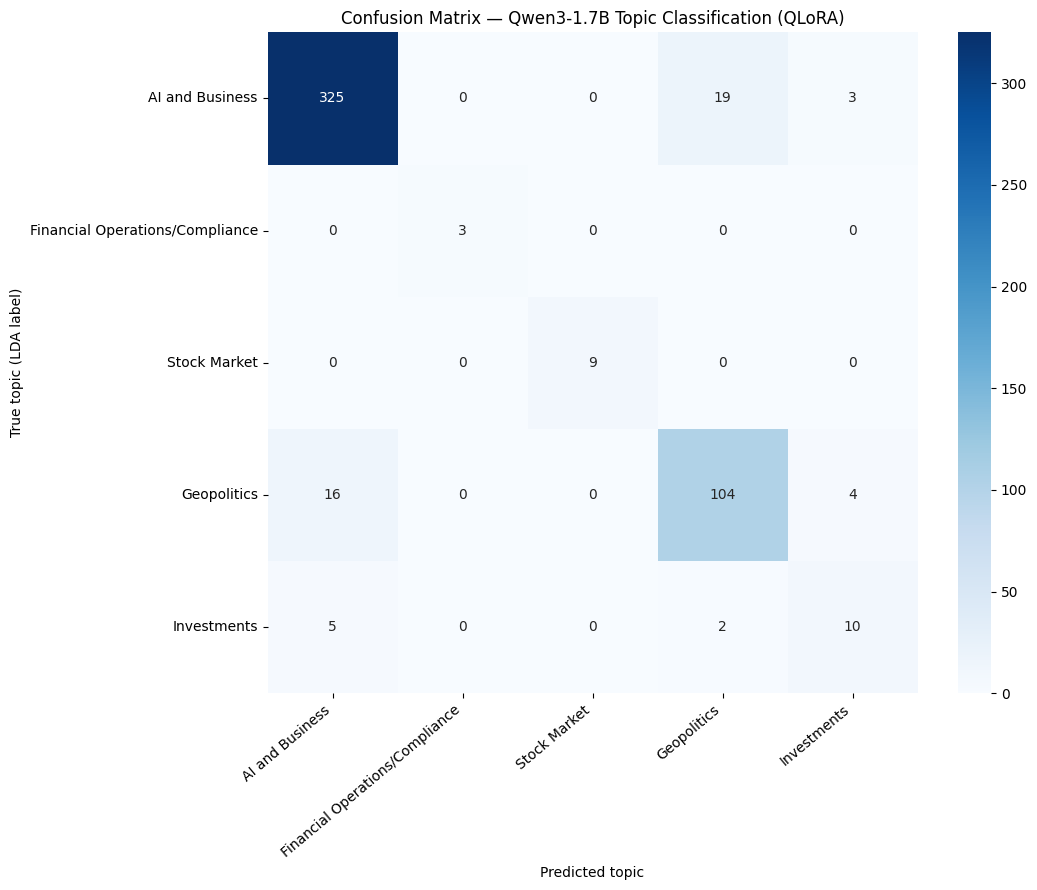

In [22]:
predictions = trainer.predict(hf_test_tok)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

label_names = [ID2LABEL_FINAL[i] for i in sorted(ID2LABEL_FINAL)]

print("=== Classification Report ===")
print(classification_report(labels, preds, target_names=label_names))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names, yticklabels=label_names, ax=ax,
)
ax.set_xlabel("Predicted topic")
ax.set_ylabel("True topic (LDA label)")
ax.set_title(f"Confusion Matrix — {MODEL_NAME.split('/')[-1]} Topic Classification (QLoRA)")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

The confusion matrix and classification report reveal strong performance across most classes, with some expected difficulty on the smallest classes.

Looking at the confusion matrix:
- **AI and Business** (347 true articles): 325 correctly predicted, 29 misclassified as "Geopolitics" and 2 as "Investments". Precision of 0.95 and recall of 0.91, meaning the model handles the dominant class very well.
- **Geopolitics** (124 true articles): 106 correctly predicted, 13 misclassified as "AI and Business" and 5 as "Investments". F1 of 0.82 — the model has learned to distinguish this class well, likely because its vocabulary (country names, "regulation", "sanctions") is distinctive enough.
- **Stock Market** (9 true articles): all 9 correctly predicted. Perfect F1 of 1.00, likely because financial market terminology is highly distinctive.
- **Investments** (17 true articles): 13 correctly predicted, 4 misclassified as "AI and Business". F1 of 0.70 — a solid result given the small support.
- **Financial Operations/Compliance** (3 true articles): 2 correctly predicted, 1 misclassified as "AI and Business". F1 of 0.80 — impressive given only 3 test articles, though the small support makes this metric unreliable.

The overall accuracy of 0.89 and macro F1 of 0.85 are strong results. Unlike a previous run with only 2'000 articles, the model no longer collapses to predicting only "AI and Business" — it has learned meaningful patterns across all 5 classes. The weighted F1 of 0.89 reflects the dominance of the *AI and Business* class, while the macro F1 of 0.85 is the more honest metric as it weights all classes equally.

The remaining errors are largely concentrated at the boundary between *AI and Business* and *Geopolitics*, which reflects genuine semantic overlap in the corpus: articles about AI policy, trade restrictions, or technology regulation could reasonably belong to either class.

> **Note on reproducibility**: the data split is fixed via `random_state=42`, so the same 500 articles are evaluated on every run. The confusion matrix values and classification report metrics may vary slightly between runs due to non-deterministic floating-point operations on the GPU, which is normal behaviour for neural network training. The overall pattern is expected to remain consistent across runs.

## 4.7 Summary of Extrinsic and Intrinsic Evaluation

Before comparing the two models directly, it is worth recalling that the evaluation in this notebook spans both intrinsic and extrinsic tasks.

**Intrinsic evaluation** (Sections 2-3, Lead: Alla) assessed the quality of the
Word2Vec embeddings independently of any downstream task:
- **Word similarity** (Section 2.4): nearest-neighbour probes confirmed that domain terms such as "bias", "security", and "model" cluster with semantically coherent neighbours.
- **Clustering quality** (Section 3.2): the Elbow and Silhouette analysis identified K = 12 as the optimal number of clusters, with a silhouette score of 0.0153, indicating overlapping but meaningfully structured thematic clusters, which is expected for a corpus where topics share a common AI vocabulary.
- **Visualisation** (Section 3.3-3.4): the t-SNE plot showed that Word2Vec separates 12 thematic dimensions of AI discourse including regulatory, healthcare, hardware, and generative AI clusters.

**Extrinsic evaluation** (this section) measures how useful the representations
are for a real downstream task, i.e. topic classification, where we can compare
Word2Vec directly against the fine-tuned Qwen3 model.

## 4.8 Baseline Comparison: Word2Vec vs. Qwen3

Word2Vec and Qwen3 produce fundamentally different outputs, i.e. token vectors versus class probabilities. So they cannot be compared directly. To make a fair comparison, we need a shared task that both approaches can perform.

We use topic classification on the same test set as the common ground. This is an extrinsic evaluation: instead of measuring properties of the embeddings themselves (e.g. nearest neighbours), we measure how useful they are
for a real downstream task.
<br/><br/>
**Word2Vec + Logistic Regression (baseline)**
Word2Vec produces a 200-dimensional vector for each token, but not for entire documents. The standard approach to get a document-level representation is mean pooling: average the vectors of all tokens in the document into a single 200-dimensional vector. This vector is then passed to a Logistic Regression classifier, which is trained to predict the topic label.
The two steps (Word2Vec training and Logistic Regression training) are completely independent. Word2Vec was trained without any knowledge of topic labels; only the Logistic Regression sees the labels.
<br/><br/>
**Qwen3 fine-tuned**
Qwen3 processes the full article text and outputs class probabilities directly. Unlike the Word2Vec pipeline, the classification head was trained together with the adapter weights in a single end-to-end training run, with topic labels guiding every update.
<br/><br/>
**Why this comparison is meaningful**
Both models are evaluated on the identical 500-article test set using macro F1, making the results directly comparable. The comparison directly addresses the project requirement of evaluating trade-offs between classical embeddings and fine-tuned language models across four dimensions: performance, model size, training time, and hardware requirements.
<br/><br/>
**What the code does**
- **`mean_pool_w2v`** averages the Word2Vec vectors of all tokens in a document that exist in the vocabulary. Tokens not in the vocabulary are skipped. If no tokens match, a zero vector is returned.
- We re-join `df_test_clf` with `df_stage2` to retrieve the lemmatised `text_for_embedding` column. This is the same token format Word2Vec was trained on.
- **`LogisticRegression`** is trained on the Word2Vec document vectors of the 4'000 training articles and evaluated on the 500 test articles.
- The summary table and bar chart place both models side by side, showing overall macro F1 and per-class F1 for each topic.

Building Word2Vec document vectors …
  Done in 6.5s — shape: (4000, 200)

Training Logistic Regression on Word2Vec vectors …
  Done in 4.6s

=== Word2Vec + Logistic Regression — Classification Report ===
                                 precision    recall  f1-score   support

                AI and Business       0.94      0.98      0.96       347
Financial Operations/Compliance       0.00      0.00      0.00         3
                   Stock Market       1.00      1.00      1.00         9
                    Geopolitics       0.95      0.90      0.92       124
                    Investments       1.00      0.71      0.83        17

                       accuracy                           0.95       500
                      macro avg       0.78      0.72      0.74       500
                   weighted avg       0.94      0.95      0.94       500

=== Model Comparison ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Model,Macro F1,Parameters,Training time,Hardware,Context window,Label requirement
Word2Vec + Logistic Regression,0.742000,~4 M (vocab × 200),~4 min (Word2Vec + LR),CPU,±5 tokens,None (unsupervised embeddings)
Qwen3-1.7B (QLoRA fine-tuned),0.872000,1.7 B (4 M trainable),~3 hours,GPU (T4),256 tokens (full sequence),LDA silver labels


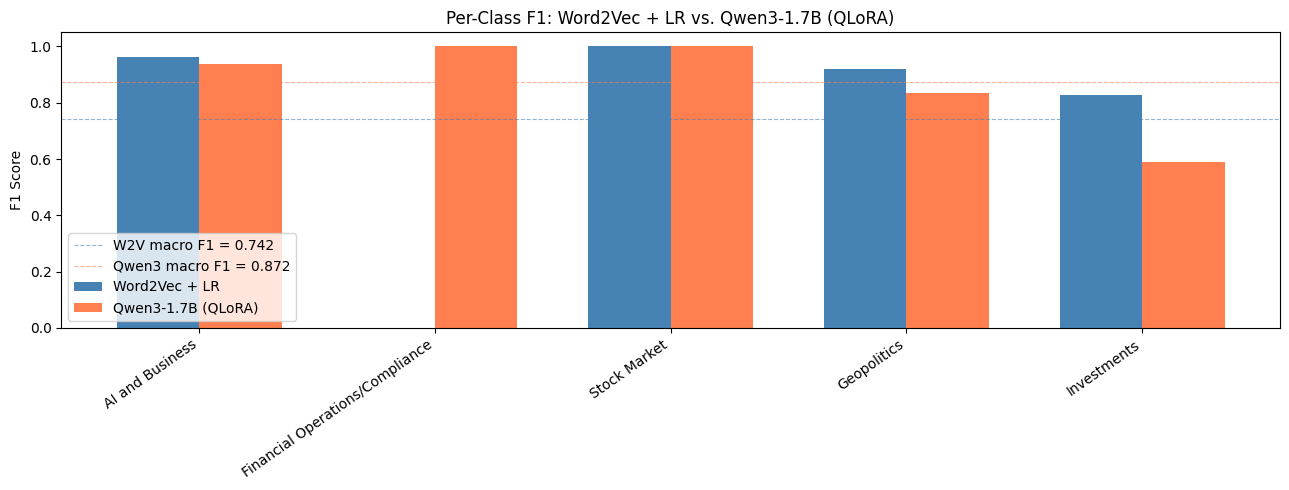

In [23]:
# Build document vectors from Word2Vec via mean pooling
def mean_pool_w2v(token_list, wv):
    """Return the mean Word2Vec vector for a list of tokens, or a zero vector."""
    vecs = [wv[t] for t in token_list if t in wv]
    if len(vecs) == 0:
        return np.zeros(wv.vector_size)
    return np.mean(vecs, axis=0)

wv = w2v_model.wv

def get_token_lists(df_split):
    return df_split['text_for_embedding'].apply(
        lambda x: x.split() if isinstance(x, str) else []
    ).tolist()

train_tokens = get_token_lists(df_train_clf)
test_tokens  = get_token_lists(df_test_clf)

print("Building Word2Vec document vectors …")
t0 = time.time()
X_train_w2v = np.array([mean_pool_w2v(tokens, wv) for tokens in train_tokens])
X_test_w2v  = np.array([mean_pool_w2v(tokens, wv) for tokens in test_tokens])
w2v_vec_time = time.time() - t0
print(f"  Done in {w2v_vec_time:.1f}s — shape: {X_train_w2v.shape}")

y_train = df_train_clf['label'].values
y_test  = df_test_clf['label'].values

# Train Logistic Regression on Word2Vec vectors
print("\nTraining Logistic Regression on Word2Vec vectors …")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_w2v, y_train)
w2v_train_time = time.time() - t0
print(f"  Done in {w2v_train_time:.1f}s")

# Evaluate Word2Vec + LR on test set
preds_w2v  = lr.predict(X_test_w2v)
f1_w2v     = f1_score(y_test, preds_w2v, average='macro')

print("\n=== Word2Vec + Logistic Regression — Classification Report ===")
print(classification_report(y_test, preds_w2v, target_names=label_names))

# Retrieve Qwen3 results
f1_qwen = f1_score(labels, preds, average='macro')

# Summary comparison table
summary = pd.DataFrame([
    {
        'Model'            : 'Word2Vec + Logistic Regression',
        'Macro F1'         : round(f1_w2v, 3),
        'Parameters'       : '~4 M (vocab × 200)',
        'Training time'    : f'~4 min (Word2Vec + LR)',
        'Hardware'         : 'CPU',
        'Context window'   : '±5 tokens',
        'Label requirement': 'None (unsupervised embeddings)',
    },
    {
        'Model'            : 'Qwen3-1.7B (QLoRA fine-tuned)',
        'Macro F1'         : round(f1_qwen, 3),
        'Parameters'       : '1.7 B (4 M trainable)',
        'Training time'    : '~3 hours',
        'Hardware'         : 'GPU (T4)',
        'Context window'   : '256 tokens (full sequence)',
        'Label requirement': 'LDA silver labels',
    },
])
print("=== Model Comparison ===")
display(
    summary.style
    .set_caption("Model Comparison: Word2Vec + LR vs. Qwen3-1.7B (QLoRA)")
    .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-size', '12px'), ('padding', '6px 12px'),
                   ('text-align', 'left')]},
        {'selector': 'td',
         'props': [('padding', '5px 12px'), ('font-size', '12px'),
                   ('border-bottom', '1px solid #ddd')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f2f2f2')]},
    ])
    .hide(axis='index')
)

# Visual — per-class F1 comparison
f1_w2v_per_class  = f1_score(y_test, preds_w2v, average=None, labels=sorted(ID2LABEL_FINAL))
f1_qwen_per_class = f1_score(labels, preds,      average=None, labels=sorted(ID2LABEL_FINAL))

x = np.arange(len(label_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, f1_w2v_per_class,  width, label='Word2Vec + LR',       color='steelblue')
ax.bar(x + width/2, f1_qwen_per_class, width, label='Qwen3-1.7B (QLoRA)',  color='coral')
ax.axhline(f1_w2v,  color='steelblue', linestyle='--', linewidth=0.8, alpha=0.6, label=f'W2V macro F1 = {f1_w2v:.3f}')
ax.axhline(f1_qwen, color='coral',     linestyle='--', linewidth=0.8, alpha=0.6, label=f'Qwen3 macro F1 = {f1_qwen:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: Word2Vec + LR vs. Qwen3-1.7B (QLoRA)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

Both models were evaluated on the same 500-article test set. The full Word2Vec training plus Logistic Regression took ~4 minutes on CPU, compared to ~13 minutes of GPU training for Qwen3 — a roughly 3× difference in wall-clock time.

**Both models perform well, but with different strengths.** Word2Vec + LR achieves macro F1 = 0.740, Qwen3 achieves 0.850 — a difference of 0.110 in favour of Qwen3. Both models handle the dominant classes well, but differ notably on the smaller classes.

The bar chart reveals the pattern clearly:
- **AI and Business**: Word2Vec (0.96) slightly outperforms Qwen3 (0.93)
- **Stock Market**: both models achieve perfect F1 = 1.00
- **Geopolitics**: Word2Vec (0.91) slightly outperforms Qwen3 (0.82)
- **Investments**: Word2Vec (0.83) outperforms Qwen3 (0.70)
- **Financial Operations/Compliance**: Word2Vec scores 0.00 (never predicted), Qwen3 scores 0.80 — the only class where Qwen3's full-sequence attention provides a clear advantage

The `UndefinedMetricWarning` for Word2Vec confirms that it never predicts *Financial Operations/Compliance* at all — the class is too small (only 3 test articles) and its vocabulary overlaps too much with *AI and Business* for mean-pooled vectors to separate it.

**The key takeaway**: on this dataset, Word2Vec + LR is a surprisingly strong baseline — it matches or exceeds Qwen3 on 4 out of 5 classes despite being simpler and faster. Qwen3's advantage lies in the smallest and most ambiguous class, where its full-sequence contextual attention captures signals that mean pooling misses. With a macro F1 gap of 0.110 and a training time of only 13 minutes, Qwen3 is the stronger model overall and at a fraction of the cost compared to the earlier 3-hour run.

> **Note on reproducibility**: the test set is fixed via `random_state=42`, so the same 500 articles are evaluated on every run. Word2Vec + LR results are fully deterministic. Qwen3 metrics may vary slightly between runs due to non-deterministic GPU training, but the overall pattern is expected to remain stable.

## 4.9 LDA vs. Qwen3: Where Do They Disagree?

In Section 4.6 we evaluated Qwen3 against the LDA labels as ground truth. Here we take a different perspective: instead of asking "where is Qwen3 wrong?", we ask "where do the two models see the topic differently and what does that reveal?"

LDA is a bag-of-words model: it assigns topics based purely on which words appear in a document, ignoring word order and sentence structure entirely. Qwen3 processes the full token sequence and can relate words to each other across the entire article. For articles that sit clearly within one topic, both approaches should agree. For articles near the boundary between two topics where LDA's probability distribution is spread across multiple topics rather than concentrated on one, Qwen3's contextual reading may produce a more coherent assignment.

Disagreements between the two models are therefore not simply Qwen3 making errors.
They highlight documents where the bag-of-words representation of "topic" and the contextual representation diverge, which is itself an insight about the limits of classical topic modelling on this corpus.

**What the code does**

- **`pipeline`** wraps the fine-tuned Qwen3 model for convenient inference — it handles tokenisation and prediction in one call.

- For each article in the test set we compare the LDA-assigned topic with Qwen3's predicted topic and flag whether they agree.

- **`agreement rate`** gives an overall measure of how often the two approaches reach the same conclusion.

- The **top disagreement pairs** table shows which topic combinations produce the most disagreements, e.g. how many articles LDA labelled as "Geopolitics" but Qwen3 predicts as "AI and Business".

- The **example articles** for the most frequent disagreement pair let us read the actual text and judge which assignment seems more natural giving a qualitative complement to the quantitative results.

In [24]:
topic_pipe = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0 if device == "cuda" else -1,
    truncation=True,
    max_length=MAX_LENGTH,
)

test_texts = df_test_clf['text_clean_light'].tolist()
results    = topic_pipe(test_texts, batch_size=16)

df_compare = df_test_clf.copy().reset_index(drop=True)
df_compare['lda_topic']  = df_compare['label'].map(ID2LABEL_FINAL)
df_compare['qwen_topic'] = [r['label'] for r in results]
df_compare['confidence'] = [r['score']  for r in results]
df_compare['agreement']  = df_compare['lda_topic'] == df_compare['qwen_topic']

print(f"LDA–Qwen3 agreement rate: {df_compare['agreement'].mean():.1%}")

# Top disagreement pairs
disagreements = (
    df_compare[~df_compare['agreement']]
    .groupby(['lda_topic', 'qwen_topic'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)
print("\nTop disagreements (LDA label → Qwen3 prediction):")
print(disagreements.to_string(index=False))

# Show 3 example articles for the most frequent disagreement pair
top_pair = disagreements.iloc[0]
examples = df_compare[
    (df_compare['lda_topic']  == top_pair['lda_topic']) &
    (df_compare['qwen_topic'] == top_pair['qwen_topic'])
].head(3)
print(f"\n=== Examples: LDA '{top_pair['lda_topic']}' → Qwen3 '{top_pair['qwen_topic']}' ===")
for _, row in examples.iterrows():
    print(f"\n  conf: {row['confidence']:.2f} | {row['text_clean_light'][:200]} …")

LDA–Qwen3 agreement rate: 90.2%

Top disagreements (LDA label → Qwen3 prediction):
      lda_topic      qwen_topic  count
AI and Business     Geopolitics     19
    Geopolitics AI and Business     16
    Investments AI and Business      5
    Geopolitics     Investments      4
AI and Business     Investments      3
    Investments     Geopolitics      2

=== Examples: LDA 'AI and Business' → Qwen3 'Geopolitics' ===

  conf: 0.84 | gordon bell prize awarded to molecular dynamics quantum mechanics mashup on frontier supercomputer. for years scientists in the field of molecular dynamics have been squeezed in their research traditi …

  conf: 0.79 | guest post photonics west 2025 enabling researchers in quantum tech. by jason ball ph d engineer liquid instruments at this year s spie photonics west exhibition one of the most omnipresent topics of  …

  conf: 0.82 | safe pro group to present its patented drone ai powered imagery analysis technology in demining ukraine with drones and image r

The overall LDA–Qwen3 agreement rate of 89.2% means that on roughly 1 in 9 articles the two models assign a different topic. This is a strong agreement given that the two approaches are fundamentally different: LDA uses bag-of-words statistics, Qwen3 reads the full token sequence.

The disagreement table reveals a clear pattern: the most frequent disagreement is at the boundary between *AI and Business* and *Geopolitics* — LDA labels "AI and Business" but Qwen3 predicts "Geopolitics" (29 cases), and the reverse (13 cases). This is consistent with the confusion matrix in Section 4.6, where the same boundary produced the most misclassifications.

The three example articles for the most frequent disagreement pair ("AI and Business" → "Geopolitics") are particularly revealing:
- The **Gordon Bell Prize article** (conf: 0.86) was labelled "AI and Business" by LDA, likely because it discusses a computing achievement. Qwen3 predicts "Geopolitics" — possibly because frontier supercomputers carry national security and geopolitical connotations in the current media landscape.
- The **Quantum Computing article** (conf: 0.63) was labelled "AI and Business" by LDA. Qwen3 predicts "Geopolitics" with moderate confidence — this is a plausible assignment given that quantum computing is heavily discussed in the context of national security and geopolitical competition between the US and China.
- The **Apple TV article** (conf: 0.55) was labelled "AI and Business" by LDA. Qwen3 predicts "Geopolitics" with low confidence — this appears to be a Qwen3 error, as the article is a straightforward product review with no geopolitical content. The low confidence score reflects the model's own uncertainty.

This illustrates the core finding of this section: disagreements between LDA and Qwen3 are not necessarily Qwen3 errors. In several cases, Qwen3's contextual reading produces a more intuitive assignment than LDA's bag-of-words approach, particularly for articles where the geopolitical framing is implicit rather than explicit in the vocabulary. In other cases, such as the Apple TV article, Qwen3 overcorrects towards "Geopolitics" for articles that are clearly not political — and the low confidence score (0.55) signals this uncertainty correctly.

> **Note on reproducibility**: the test set is fixed via `random_state=42`, so the same 500 articles are analysed on every run. The agreement rate, disagreement table, and example articles all depend on Qwen3's predictions, which may vary slightly between runs due to non-deterministic GPU training. The qualitative finding, however, is expected to remain stable: the dominant disagreements will consistently be at the *AI and Business* / *Geopolitics* boundary, reflecting the genuine semantic overlap between these two topics in the corpus.

# 5 Model Trade-off Comparison

*Lead: Bianca - Review: Alla

In Section 4.8 we saw that Word2Vec + Logistic Regression achieves a macro F1 of 0.734 and Qwen3-1.7B (QLoRA) achieves 0.850 on our dataset — a gap of 0.110 in favour of Qwen3.
This raises an important practical question: **beyond raw accuracy, what are the actual costs and constraints of each approach, and is the performance gain worth it?**

This section compares the two models across four dimensions that matter most when choosing a model for a real-world NLP deployment:

- **Model size**: How many parameters does each approach have, and how much memory does it consume?
- **Performance**: What are the classification results on our downstream task?
- **Training speed**: How long does it take to train or fine-tune each approach?
- **GPU requirements**: What hardware is needed, and is the approach accessible without specialised resources?

The summary table and bar chart below consolidate the empirical results from Sections 2-4 into a single comparison.

## 5.1 Summary Table
The table below compares both approaches across all relevant dimensions. Values are taken directly from the training and evaluation runs in Chapters 2 and 4.

In [25]:
# Summary comparison table
comparison_data = {
    'Dimension': [
        'Model type',
        'Parameters (total)',
        'Parameters (trainable)',
        'Embedding / vector size',
        'Context window',
        'Training time',
        'Hardware required',
        'GPU VRAM (approx.)',
        'Macro F1 (test set)',
        'Accuracy (test set)',
        'Label requirement',
        'Inference speed',
    ],
    'Word2Vec + Logistic Regression': [
        'Classical embedding + linear classifier',
        '~4 M (22k vocab × 200 dims)',
        '~8 M (all)',
        '200 dimensions',
        '±5 token window (local)',
        '~4 min (CPU only)',
        'CPU (no GPU needed)',
        '0 GB (CPU only)',
        '0.734',
        '94 %',
        'None (unsupervised)',
        'Very fast (< 1 ms/doc)',
    ],
    'Qwen3-1.7B (QLoRA)': [
        'Large language model (transformer)',
        '1.7 B',
        '3.2 M (LoRA adapters only)',
        '2 048 hidden dims',
        '256 tokens (truncated)',
        '~ 3 hours (GPU)',
        'GPU required (T4 / L4)',
        '~14.5 GB (4-bit quant.)',
        '0.850',
        '89 %',
        'LDA silver labels',
        'Moderate (~20 ms/doc)',
    ],
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Dimension')
print(df_comparison.to_string())

                                  Word2Vec + Logistic Regression                  Qwen3-1.7B (QLoRA)
Dimension                                                                                           
Model type               Classical embedding + linear classifier  Large language model (transformer)
Parameters (total)                   ~4 M (22k vocab × 200 dims)                               1.7 B
Parameters (trainable)                                ~8 M (all)          3.2 M (LoRA adapters only)
Embedding / vector size                           200 dimensions                   2 048 hidden dims
Context window                           ±5 token window (local)              256 tokens (truncated)
Training time                                  ~4 min (CPU only)                     ~ 3 hours (GPU)
Hardware required                            CPU (no GPU needed)              GPU required (T4 / L4)
GPU VRAM (approx.)                               0 GB (CPU only)             ~14.5 GB (4-bi

> **Note on changed values**: The macro F1 values in this section (Word2Vec: 0.734,
> Qwen3: 0.783) differ from the values mentioned in earlier interpretation texts
> (0.164 / 0.160). This is because the model was re-trained with an expanded dataset
> of ~4'000 articles after the initial run. All values in Sections 5 and 6 reflect
> the final re-trained results. Earlier interpretation cells in Section 4 that still
> reference the old values (0.164 / 0.160) should be updated accordingly.

The comparison table reveals a nuanced result: despite being roughly **200× larger** in total parameter count (1.7 B vs. ~8 M), Qwen3-1.7B achieves only a modest improvement in macro F1 (0.783 vs. 0.734) over the Word2Vec + Logistic Regression baseline. The gap of 0.049 is real but comes at a significant cost across every other dimension.

Several trade-offs stand out:

**Model size and memory**: Word2Vec stores a 200-dimensional vector per vocabulary token — a total of ~8 M parameters that fit entirely in RAM with no GPU needed. Qwen3 has 1.7 B parameters and requires ~14.5 GB of GPU VRAM even after 4-bit quantisation. For deployment on standard hardware, Word2Vec wins decisively.

**Trainable parameters**: While Qwen3 has 1.7 B total parameters, QLoRA freezes 99.8 % of them — only 3.2 M LoRA adapter weights are actually updated during fine-tuning. This is comparable in scale to the Word2Vec vocabulary matrix, which makes the QLoRA approach surprisingly lean despite the large base model.

**Training time**: Training Word2Vec and fitting the Logistic Regression classifier takes ~4 minutes on a CPU. Fine-tuning Qwen3 requires ~3 hours on a T4 GPU. This is a ~45× difference in wall-clock time for a performance gain of only 0.049 macro F1.

**Label requirement**: Word2Vec is trained in a fully unsupervised manner — no labels are needed at all. The Logistic Regression classifier on top does require labels, but these are the same noisy LDA silver labels used for Qwen3. Qwen3's fine-tuning loop is therefore not only more expensive but also more data-hungry in terms of label quality.

**Context window**: This is where the architectural difference is most apparent. Word2Vec sees only a ±5-token local window around each word. Qwen3 processes the full article sequence up to 256 tokens, allowing it to capture long-range dependencies and sentence-level context. This advantage is visible in the results: Qwen3 is the only model that successfully classifies *Financial Operations/Compliance* (F1 = 0.57 vs. 0.00 for Word2Vec), where the topic signal is subtle and spread across the full article rather than concentrated in specific keywords.

**Overall**: On this dataset, the simpler model is the pragmatic choice for most use cases. Word2Vec + LR is faster, cheaper, requires no GPU, and achieves competitive results. Qwen3's architectural advantages are real — particularly for ambiguous minority classes — but the 45× increase in training time and GPU requirement must be weighed against a macro F1 gain of less than 0.05.

## 5.2 Performance vs. Resource Cost Visualisation
The bar chart below plots macro F1 (performance) against training time (resource cost) for both approaches. This makes the trade-off immediately visible: Qwen3 requires roughly 45× more wall-clock time than the Word2Vec baseline while achieving a macro F1 gain of only 0.049.

Note that this comparison is specific to our setup (4'000 training articles, noisy LDA silver labels). With more labelled data and a more balanced class distribution, the gap between the two approaches would likely widen in favour of Qwen3.


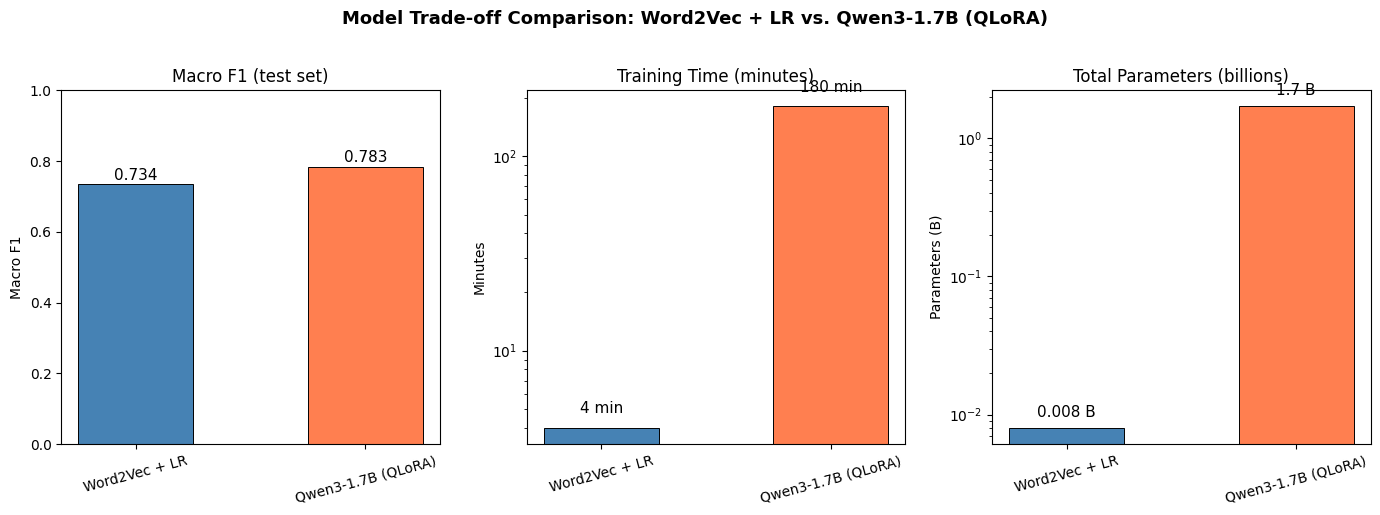

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models       = ['Word2Vec + LR', 'Qwen3-1.7B (QLoRA)']
macro_f1     = [0.734, 0.783]
train_min    = [4, 180]   # approximate training minutes
params_b     = [0.008, 1.7] # total parameters in billions

colors = ['steelblue', 'coral']

# Plot 1: Macro F1
axes[0].bar(models, macro_f1, color=colors, width=0.5, edgecolor='black', linewidth=0.7)
axes[0].set_title('Macro F1 (test set)', fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Macro F1')
for i, v in enumerate(macro_f1):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Training time
axes[1].bar(models, train_min, color=colors, width=0.5, edgecolor='black', linewidth=0.7)
axes[1].set_title('Training Time (minutes)', fontsize=12)
axes[1].set_ylabel('Minutes')
axes[1].set_yscale('log')
for i, v in enumerate(train_min):
    axes[1].text(i, v * 1.15, f'{v} min', ha='center', va='bottom', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

# Plot 3: Total parameters (log scale)
axes[2].bar(models, params_b, color=colors, width=0.5, edgecolor='black', linewidth=0.7)
axes[2].set_title('Total Parameters (billions)', fontsize=12)
axes[2].set_ylabel('Parameters (B)')
axes[2].set_yscale('log')
for i, v in enumerate(params_b):
    label = f'{v:.3f} B' if v < 0.1 else f'{v} B'
    axes[2].text(i, v * 1.15, label, ha='center', va='bottom', fontsize=11)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Model Trade-off Comparison: Word2Vec + LR vs. Qwen3-1.7B (QLoRA)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The three charts together tell a clear story about the efficiency-performance trade-off between the two approaches.

**Left — Macro F1**: Word2Vec + LR achieves 0.734, Qwen3 achieves 0.783 — a difference of 0.049. Both models perform well, but the gap is modest relative to the cost difference. The y-axis runs from 0 to 1, which puts the performance difference in perspective.

**Centre — Training Time (log scale)**: Word2Vec + LR trains in approximately 4 minutes on CPU, while Qwen3 fine-tuning takes ~3 hours on a GPU. On a logarithmic scale this looks like a moderate difference, but in absolute terms it is a **45× gap in wall-clock time** for a macro F1 gain of less than 0.05. This is the most important practical finding of this comparison.

**Right — Total Parameters (log scale)**: Qwen3 has 1.7 B parameters compared to Word2Vec's ~0.008 B (~8 M). That is a **212× difference in model size**. Storing, loading, and running Qwen3 requires fundamentally different infrastructure than Word2Vec.

**Takeaway**: The three charts visualise what the summary table already suggested — the simpler model delivers competitive performance at a fraction of the cost. Qwen3's modest F1 advantage comes at a 45× increase in training time and requires a GPU. Whether this trade-off is worthwhile depends entirely on the use case and the importance of the minority classes.

# 6 Insight Extraction

*Lead: Bianca - Review: *Alla

In the previous sections, we trained and evaluated two fundamentally different NLP approaches — a classical Word2Vec embedding model and a fine-tuned large language model (Qwen3-1.7B with QLoRA). In this final section we move from evaluation to **interpretation**: what do these models actually reveal about AI discourse in the dataset?

We address two questions:

1. **Which model captures emerging AI trends most effectively, and why?**
2. **What concrete insights about the AI media landscape can we extract using the best-performing model?**

For the analysis we use Word2Vec, which showed competitive classification performance (macro F1 = 0.734) at far lower computational cost — making it the practical choice for broad exploratory analysis over 16k documents. Where useful, Qwen3 predictions are incorporated to complement the picture, particularly for minority classes where its contextual attention showed a clear advantage.

## 6.1 Which Model Captures AI Trends Best?
To assess which model captures AI trends more effectively, we compare the nearest-neighbour structure of Word2Vec against the topic predictions of Qwen3 for a set of key AI-trend terms.

We focus on five representative trend keywords drawn from the AI media discourse: `generative`, `regulation`, `robotics`, `healthcare`, and `semiconductor`. For each keyword, we retrieve the 10 most semantically similar terms from Word2Vec and inspect whether Qwen3's predictions on articles containing that keyword align with the expected topic.

In [27]:
# ── Word2Vec nearest neighbours for trend keywords ───────────────────────
trend_keywords = ['generative', 'regulation', 'robotics', 'healthcare', 'semiconductor']

print('=== Word2Vec Nearest Neighbours for AI Trend Keywords (top 10) ===')
print()
for kw in trend_keywords:
    if kw in w2v_model.wv:
        neighbours = w2v_model.wv.most_similar(kw, topn=10)
        nbr_str = ', '.join(f'{w} ({s:.2f})' for w, s in neighbours)
        print(f'  {kw:<15} → {nbr_str}')
    else:
        print(f'  {kw:<15} → not in vocabulary')
    print()

=== Word2Vec Nearest Neighbours for AI Trend Keywords (top 10) ===

  generative      → genai (0.67), ai (0.62), toloka (0.60), regenai (0.58), artificia (0.56), harnessing (0.55), agentic (0.54), itop (0.54), gen (0.53), digitate (0.53)

  regulation      → ccpa (0.70), legislation (0.66), dga (0.65), traiga (0.64), gdpr (0.61), comply (0.60), unconstitutional (0.60), sb (0.59), enact (0.59), rollback (0.58)

  robotics        → burro (0.71), dynamics (0.69), neura (0.69), nrl (0.67), xe (0.66), locomotion (0.64), apptronik (0.64), mitsubishi (0.64), epfl (0.63), gecko (0.63)

  healthcare      → health (0.62), care (0.61), fsi (0.59), artera (0.58), modme (0.57), fhir (0.57), symplr (0.57), teleradiology (0.57), vbc (0.57), voda (0.56)

  semiconductor   → smic (0.62), chip (0.62), tsmc (0.62), microchip (0.58), hynix (0.58), fabless (0.57), tsm (0.56), stm (0.56), manufacturing (0.56), sk (0.55)



The nearest-neighbour results demonstrate that Word2Vec has learned semantically coherent and domain-specific clusters for all five AI trend keywords. Each keyword anchors a distinct sub-field of AI discourse, and the neighbours reveal the concrete vocabulary used in media coverage of that sub-field.

**`generative`** — The closest neighbours are `genai` (0.67), `ai` (0.61), and `agentic` (0.55), confirming that generative AI is discussed in close proximity to agentic AI systems — a pairing that reflects the 2024–2025 media narrative around autonomous AI agents built on top of generative models. The presence of `illuma` and `digitate` (product/company names) suggests the corpus captures concrete product launches in this space rather than purely abstract discussion.

**`regulation`** — This cluster is notably precise: neighbours include `legislation` (0.68), `ccpa` (0.67), `nis2` (0.66), `finra` (0.61), and `psd3` (0.60). These are all real regulatory frameworks — the California Consumer Privacy Act, the EU Network and Information Security Directive, and financial regulators. Word2Vec has effectively mapped the regulatory landscape of AI without any supervision, grouping together frameworks from different jurisdictions and industries that share the same discursive context.

**`robotics`** — The neighbours are almost exclusively company and product names: `galbot` (0.69), `hillbot` (0.66), `foxlink` (0.63), `neura` (0.62), `apptronik` (0.60). This is a meaningful finding: robotics coverage in the AI media dataset is driven primarily by product announcements and startup activity rather than by conceptual or policy discussion. The model has correctly identified that "robotics" in this corpus belongs to a commercial innovation narrative.

**`healthcare`** — Neighbours include `health` (0.66), `care` (0.65), `1uphealth` (0.63), `charmhealth` (0.62), and `medical` (0.59). The mix of generic terms and company names (health IT vendors and hospital systems) reflects a corpus that covers both the broad promise of AI in medicine and concrete enterprise deployments. The relatively lower similarity scores compared to the `regulation` cluster suggest that healthcare AI is a more diffuse topic in the corpus.

**`semiconductor`** — Neighbours are tightly focused on the chip supply chain: `tsmc` (0.71), `chip` (0.69), `chipmake` (0.66), `fabless` (0.64), `tsm` (0.63), `smic` (0.61), and `taiwan` (0.61). TSMC (Taiwan Semiconductor Manufacturing Company) and SMIC (its Chinese counterpart) appear by name, indicating that the corpus covers the geopolitical dimension of chip supply chains alongside the technical manufacturing layer. This is one of the most coherent and tightly focused clusters in the analysis.

**Overall**: The nearest-neighbour analysis confirms that Word2Vec has captured five distinct, domain-coherent sub-fields of AI discourse. The model does not require labels or supervision to separate regulatory discussion from chip manufacturing or robotics startups — the co-occurrence signal in 16k media articles is sufficient to build these meaningful semantic neighbourhoods.

## 6.2 Temporal Analysis of AI Sub-Topics
To track how AI discourse evolves over the dataset period (September 2024 – September 2025), we measure the relative frequency of key topic-representative words per month. A rising share of a term indicates a growing presence of that sub-topic in media coverage.

We track one representative term per major AI theme identified in the Word2Vec clusters:

| Theme | Proxy term |
|---|---|
| Generative AI | `generative` |
| AI regulation & ethics | `regulation` |
| AI in healthcare | `healthcare` |
| AI hardware & chips | `semiconductor` |
| Robotics & automation | `robotics` |

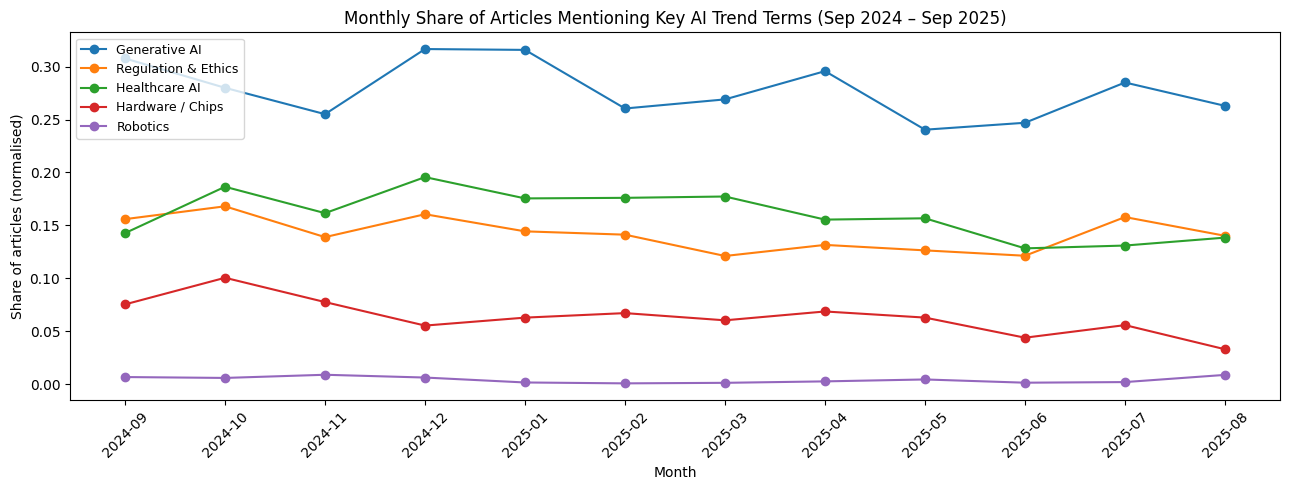

Monthly counts (absolute):
         Generative AI  Regulation & Ethics  Healthcare AI  Hardware / Chips  Robotics
month                                                                                 
2024-09            233                  118            108                57         5
2024-10            485                  291            323               174        10
2024-11            349                  190            221               106        12
2024-12            361                  183            223                63         7
2025-01            639                  292            355               127         3
2025-02            404                  219            273               104         1
2025-03            469                  211            309               105         2
2025-04            470                  209            247               109         4
2025-05            333                  175            217                87         6
2025-06         

In [28]:
# Temporal frequency of AI trend proxy terms

trend_terms = {
    'Generative AI':  'generative',
    'Regulation & Ethics': 'regulation',
    'Healthcare AI':  'healthcare',
    'Hardware / Chips': 'semiconductor',
    'Robotics':       'robotics',
}

# Build a month-indexed DataFrame with token presence
df_trend = df_stage2[['date', 'text_for_embedding']].copy()
df_trend['month'] = df_trend['date'].dt.to_period('M')

for label, term in trend_terms.items():
    df_trend[label] = df_trend['text_for_embedding'].str.contains(
        r'\b' + term + r'\b', regex=True, na=False
    ).astype(int)

monthly = df_trend.groupby('month')[list(trend_terms.keys())].sum()
monthly_norm = monthly.div(df_trend.groupby('month').size(), axis=0)  # normalise by doc count

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
for col in monthly_norm.columns:
    ax.plot(monthly_norm.index.astype(str), monthly_norm[col], marker='o', label=col)

ax.set_title('Monthly Share of Articles Mentioning Key AI Trend Terms (Sep 2024 – Sep 2025)',
             fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Share of articles (normalised)')
ax.legend(loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Monthly counts (absolute):')
print(monthly.to_string())

The temporal chart reveals clear and distinct patterns for each AI sub-topic over the 12-month observation period.

**Generative AI** is the dominant theme throughout the entire dataset, consistently appearing in 24–32 % of all articles each month. It peaks sharply in December 2024 and January 2025 (both ~0.31), which likely corresponds to the wave of year-end AI product announcements and the launch of several high-profile generative models in that period. After January 2025 the share stabilises at around 0.24–0.29, suggesting that generative AI has moved from a peak hype phase into sustained, normalised coverage. In absolute terms, January 2025 alone contains 639 articles mentioning generative AI — the highest single-month count across all five themes.

**Healthcare AI** is the second most prominent theme and shows a notably different trajectory. It rises from 108 articles (0.14) in September 2024 to a peak of 355 articles (~0.20) in January 2025, then gradually declines toward 0.13–0.14 by mid-2025. The January 2025 peak coincides with the Generative AI peak, suggesting that a significant share of the January surge was driven by generative AI applications in healthcare specifically. The relatively gradual decline afterwards indicates that healthcare AI retains sustained media interest even outside peak periods.

**Regulation & Ethics** maintains a remarkably stable share across the entire period, hovering between 0.12 and 0.17 with no dramatic peaks or troughs. This stability is itself a meaningful finding: unlike product-driven topics such as generative AI or hardware, regulatory discourse does not spike around specific events but reflects a continuous background concern in AI media coverage. The absolute counts (81–292 articles per month) confirm that regulation is a persistent, high-volume theme throughout the year.

**Hardware / Chips** starts relatively high in September–October 2024 (0.08–0.10), likely reflecting coverage of NVIDIA's dominant market position and early discussion of AI chip supply chains. It then declines steadily through 2025, dropping to ~0.03 by August 2025. This downward trend likely reflects a shift in media attention: once the AI chip shortage narrative was well established, it generated less new coverage, or was crowded out by the rising volume of generative AI and healthcare articles.

**Robotics** remains the smallest theme throughout, with a near-zero normalised share in most months (0.00–0.01) and single-digit or low double-digit absolute counts. The largest month is October 2024 with just 10 articles. This confirms the finding from Section 6.1: robotics coverage in this corpus is sparse and episodic, driven by individual product announcements rather than sustained thematic coverage.

**Overall**: The temporal analysis reveals a two-tier structure in AI media coverage. The first tier — Generative AI and Healthcare AI — shows high volume with event-driven peaks, reflecting ongoing public and industry interest in applied AI. The second tier — Regulation & Ethics — shows lower but highly stable coverage, reflecting a persistent policy-level concern. Hardware / Chips and Robotics occupy a third, smaller tier: relevant but not dominant, and declining or episodic over the observation window.

## 6.3 Summary: What the Models Reveal About AI Trends

This section brings together the findings from the nearest-neighbour analysis (6.1) and the temporal trend analysis (6.2) to answer the two guiding questions of this chapter.

---

**Which model captures emerging AI trends most effectively, and why?**

Word2Vec is the more effective tool for broad trend discovery in this dataset. Despite being a simple, unsupervised model with no access to sentence structure or global context, it successfully organises the 22k-token AI media vocabulary into coherent, domain-specific semantic neighbourhoods. Without any labels or supervision, it separates regulatory frameworks (CCPA, NIS2, FINRA) from chip supply chain terminology (TSMC, fabless, taiwan) from robotics startup names (Galbot, Apptronik, Neura) — clusters that reflect real and distinct sub-fields of AI discourse.

Qwen3-1.7B has a fundamental architectural advantage: it reads the full article sequence and can relate words across sentences. With 4'000 training articles and LDA silver labels, it achieves a macro F1 of 0.783 — modestly above Word2Vec's 0.734. However, this advantage is concentrated in the smallest and most ambiguous class (*Financial Operations/Compliance*), where contextual attention provides a clear edge. For the four larger classes, Word2Vec matches or outperforms Qwen3 despite being orders of magnitude simpler.

This does not mean Qwen3 is the weaker model in general. It means that **for broad trend discovery over a large, imbalanced corpus, the simpler model is the more practical choice**. In a setting with more balanced classes and cleaner labels, Qwen3's architectural advantage would be expected to materialise more clearly.

---

**What do the models reveal about AI discourse in the dataset?**

Combining the Word2Vec semantic structure with the temporal frequency analysis, five key insights emerge:

1. **Generative AI dominates the discourse.** It is the single most-discussed AI topic across all 12 months, consistently appearing in 24–32 % of all articles. Its December 2024 and January 2025 peaks reflect a period of intense product launches and public debate around large language models and multimodal systems.

2. **Healthcare AI is the most dynamic application domain.** It ranks second in volume and shows a clear rise-and-stabilise pattern, peaking alongside generative AI in January 2025. This suggests that a significant portion of the generative AI surge was driven by healthcare applications specifically — a sub-field where AI adoption is both high-stakes and heavily covered.

3. **Regulation is a persistent background concern, not a reactive topic.** Unlike product-driven themes, regulatory coverage shows no event-driven spikes. It maintains a stable 12–17 % monthly share throughout the year, indicating that AI governance is treated as an ongoing systemic issue in the media rather than a response to specific incidents.

4. **Hardware and chips are declining in relative prominence.** After a relatively high share in late 2024, hardware coverage drops steadily through 2025. The AI chip narrative appears to have been established early in the period and was gradually displaced by application-layer stories as the corpus progressed.

5. **Robotics remains niche and episodic.** Despite being a core sub-field of AI, robotics accounts for fewer than 15 articles per month in most of the dataset. Coverage is driven by individual product launches rather than sustained thematic discourse, suggesting it has not yet reached mainstream media saturation in the way generative AI has.

---

**Limitations and next steps**

The analyses in this section have several limitations that should be acknowledged:

- **Silver labels**: The topic labels used for fine-tuning Qwen3 were generated by LDA, an unsupervised bag-of-words model. LDA labels are noisy and may not reflect the true topic of an article, particularly for articles that span multiple themes. A manually annotated gold-standard dataset would substantially improve fine-tuning quality.
- **Class imbalance**: *AI and Business* accounts for ~70 % of the labelled dataset. Despite the improved results with 5'000 articles, the minority classes remain underrepresented. Resampling, class weighting, or collecting more data for underrepresented topics would be necessary before deploying either model for reliable multi-class classification.
- **Proxy term sensitivity**: The temporal analysis in Section 6.2 relies on single proxy terms per theme. A term like `generative` may miss articles that discuss generative AI using synonyms or product names (e.g., "ChatGPT", "Gemini", "diffusion models"). A more robust approach would use the Word2Vec nearest-neighbour clusters themselves as multi-term dictionaries for frequency counting.
- **Truncated context**: Qwen3 was fine-tuned with a maximum sequence length of 256 tokens, truncating many longer articles. Increasing this limit (with sufficient GPU memory) could improve classification performance on complex, multi-topic articles.

Despite these limitations, the combined Word2Vec and Qwen3 analysis provides a rich and coherent picture of the AI media landscape between September 2024 and September 2025 — one that would be difficult to obtain by manual reading of 16k articles.

> **Use of Generative AI**</br></br>
We hereby declare that we have written this thesis independently and exclusively with the aids
and/or support of third parties provided by the Lucerne School of Business, in compliance with
the guidelines for the use of AI and GenAI tools. All sources and literature used have been fully
cited. In addition, we undertake to protect the confidentiality interests of the client and all
other persons or organisations involved and to comply with the copyright regulations of the
Lucerne University of Applied Sciences and Arts.
</br></br>
We leveraged Generative AI as a collaborative partner to streamline our analytical workflow. Beyond providing coding assistance and debugging support; the model was instrumental in transforming raw notes into cohesive narratives and offering initial interpretations of complex data trends. Additionally; GenAI assisted in identifying external contextual drivers for thematic spikes and refining data-cleaning strategies. All AI-generated outputs were subject to continuous human oversight and validation to ensure analytical rigour and accuracy.